In [52]:
from torch.utils.data import DataLoader
import albumentations as A
from datasets import Dataset, load_from_disk
from transformers import Mask2FormerImageProcessor
import torch

In [53]:
from transformers import Mask2FormerForUniversalSegmentation


category_info = {0: 'Background', 1: 'Lower Jaw', 2: 'Tooth', 3: 'Other Bone'}


class Model:
    def __init__(self, checkpoint=None):
        if checkpoint:
            self.model = Mask2FormerForUniversalSegmentation.from_pretrained(checkpoint, local_files_only=True)
        else:
            self.model = Mask2FormerForUniversalSegmentation.from_pretrained('facebook/mask2former-swin-base-coco-panoptic', id2label=category_info, ignore_mismatched_sizes=True)


In [54]:
m = Model("saved_models/trainermodel")


In [55]:
from torch.utils.data import Dataset
import numpy as np
import torch
import io
from PIL import Image

class UJDataset(Dataset):
    """Pytorch Dataset for preprocessed lizard scans with upper jaw and skull also segmented"""

    def __init__(self, dataset, processor, transform=None):
        self.dataset = dataset
        self.processor = processor
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image = np.array(self.dataset[idx]['image'], dtype=np.float32)
        #image = np.array(Image.open(io.BytesIO(self.dataset[idx]['image']['bytes'])), dtype=np.float32)
        panoptic_seg_gt = np.array(self.dataset[idx]['label'], dtype=np.float32)

        if self.transform is not None:
            transformed = self.transform(image= image, mask= panoptic_seg_gt)
            image, panoptic_seg_gt = transformed['image'], transformed['mask']
            image = image.transpose(2,0,1)

        inst2class = {segment['id']: segment['category_id'] for segment in self.dataset[idx]['segments_info']}

        inputs = self.processor([image], [panoptic_seg_gt], instance_id_to_semantic_id=inst2class, return_tensors='pt')
        inputs = {k: v.squeeze() if isinstance(v, torch.Tensor) else v[0] for k, v in inputs.items()}
        return inputs

In [56]:
data = load_from_disk("ThreeScanDataset split.hf")
testdata = load_from_disk("ThreeScanDataset split test.hf")
processor = Mask2FormerImageProcessor(ignore_index=0, do_resize=False, do_rescale=False, do_normalize=False)

train = data['Train']
val = testdata['Test']


transform = A.Compose([
    #A.Resize(width=256, height=512),
    A.ToRGB(),
    #A.HorizontalFlip(p=1.0)
])

train_ds = UJDataset(train, processor, transform)
val_ds = UJDataset(val, processor, transform)

def collate_fn(batch):
    pixel_values = torch.stack([example["pixel_values"] for example in batch])
    pixel_mask = torch.stack([example["pixel_mask"] for example in batch])
    class_labels = [example["class_labels"] for example in batch]
    mask_labels = [example["mask_labels"] for example in batch]
    return {"pixel_values": pixel_values, "pixel_mask": pixel_mask, "class_labels": class_labels, "mask_labels": mask_labels}

train_dataloader = DataLoader(train_ds, batch_size=1, shuffle=True, collate_fn=collate_fn)
val_dataloader = DataLoader(val_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)

In [57]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
m.model.to(device)

Mask2FormerForUniversalSegmentation(
  (model): Mask2FormerModel(
    (pixel_level_module): Mask2FormerPixelLevelModule(
      (encoder): SwinBackbone(
        (embeddings): SwinEmbeddings(
          (patch_embeddings): SwinPatchEmbeddings(
            (projection): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
          )
          (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (encoder): SwinEncoder(
          (layers): ModuleList(
            (0): SwinStage(
              (blocks): ModuleList(
                (0): SwinLayer(
                  (layernorm_before): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
                  (attention): SwinAttention(
                    (self): SwinSelfAttention(
                      (query): Linear(in_features=128, out_features=128, bias=True)
                      (key): Linear(in_features=128, out_features=128, bias=True)
                      (valu

In [58]:
#outlist = []
#tlist = []
#llist = []
#image = val[30]
#inputs = val_ds[30]
#inputs['pixel_values']
#print(image)
#m.model.eval()
#with torch.no_grad():
#    o = m.model(**inputs
#    )
#    tlist.append(image)
#    outlist.append(processor.post_process_panoptic_segmentation(outputs=o, label_ids_to_fuse=[0, 1, 3], target_sizes=[torch.Tensor(image['image']).size()])[0])
#    llist.append(o.loss)


In [59]:
#print(llist[0])

In [61]:
outlist = []
tlist = []
for idx, batch in enumerate(val_dataloader):
  m.model.eval()
  with torch.no_grad():
    o = m.model(
      pixel_values=batch["pixel_values"],
      mask_labels=[labels for labels in batch["mask_labels"]],
      class_labels=[labels for labels in batch["class_labels"]]
    )
    tlist.append(batch['pixel_values'])
    outlist.append(processor.post_process_panoptic_segmentation(outputs=o, threshold=0.5, label_ids_to_fuse=[0, 1, 3], target_sizes=[batch['pixel_values'].shape[2:]])[0])
  print(idx, processor.post_process_panoptic_segmentation(outputs=o, label_ids_to_fuse=[0, 1, 3])[0]['segments_info'])

0 [{'id': 1, 'label_id': 2, 'was_fused': False, 'score': 0.991738}, {'id': 2, 'label_id': 2, 'was_fused': False, 'score': 0.924939}, {'id': 3, 'label_id': 2, 'was_fused': False, 'score': 0.993716}, {'id': 4, 'label_id': 0, 'was_fused': True, 'score': 1.0}, {'id': 5, 'label_id': 2, 'was_fused': False, 'score': 0.980798}, {'id': 6, 'label_id': 3, 'was_fused': True, 'score': 0.996689}]
1 [{'id': 1, 'label_id': 2, 'was_fused': False, 'score': 0.997554}, {'id': 2, 'label_id': 2, 'was_fused': False, 'score': 0.992729}, {'id': 3, 'label_id': 2, 'was_fused': False, 'score': 0.999414}, {'id': 4, 'label_id': 0, 'was_fused': True, 'score': 1.0}, {'id': 5, 'label_id': 1, 'was_fused': True, 'score': 0.999951}, {'id': 6, 'label_id': 3, 'was_fused': True, 'score': 0.993115}]
2 [{'id': 1, 'label_id': 2, 'was_fused': False, 'score': 0.970704}, {'id': 2, 'label_id': 2, 'was_fused': False, 'score': 0.998777}, {'id': 3, 'label_id': 2, 'was_fused': False, 'score': 0.89667}, {'id': 4, 'label_id': 2, 'was_fu

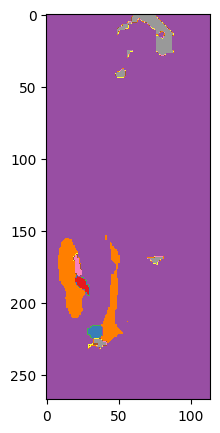

In [62]:
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib

def draw_panoptic_segmentation(segmentation, segments_info, string = None):
    # get the used color map
    viridis = plt.get_cmap('Set1')
    fig, ax = plt.subplots()
    fig.set_size_inches(10, 5)
    ax.imshow(segmentation, cmap=viridis)
    instances_counter = defaultdict(int)
    handles = []
    if string:
        plt.savefig(string)
    else:
        plt.savefig("temp.png")
    # for each segment, draw its legend
    #for segment in segments_info:
        #segment_id = segment['id']
        #segment_label_id = segment['label_id']
        #segment_label = m.model.config.id2label[segment_label_id]
        #label = f"{segment_label}-{instances_counter[segment_label_id]}"
        #instances_counter[segment_label_id] += 1
        #color = viridis(segment_id)
        #handles.append(mpatches.Patch(color=color, label=label))

    #ax.legend(handles=handles)

draw_panoptic_segmentation(outlist[11]['segmentation'].cpu(), outlist[11]['segments_info'])

In [72]:
print(np.unique(outlist[10]['segmentation']))
print(outlist[10]['segments_info'])

[0 1 2 3 4 5 6 7 8 9]
[{'id': 1, 'label_id': 2, 'was_fused': False, 'score': 0.998021}, {'id': 2, 'label_id': 3, 'was_fused': True, 'score': 0.999974}, {'id': 3, 'label_id': 2, 'was_fused': False, 'score': 0.998746}, {'id': 4, 'label_id': 2, 'was_fused': False, 'score': 0.997566}, {'id': 5, 'label_id': 1, 'was_fused': True, 'score': 0.999979}, {'id': 6, 'label_id': 2, 'was_fused': False, 'score': 0.999491}, {'id': 7, 'label_id': 2, 'was_fused': False, 'score': 0.999784}, {'id': 8, 'label_id': 0, 'was_fused': True, 'score': 1.0}, {'id': 9, 'label_id': 2, 'was_fused': False, 'score': 0.999626}]


In [73]:
print(val[10]['segments_info'])

[{'area': 26432, 'bbox': [0, 0, 114, 267], 'category_id': 0, 'id': 1891}, {'area': 643, 'bbox': [7, 149, 19, 67], 'category_id': 1, 'id': 1892}, {'area': 50, 'bbox': [19, 160, 6, 12], 'category_id': 2, 'id': 1893}, {'area': 53, 'bbox': [19, 172, 8, 8], 'category_id': 2, 'id': 1894}, {'area': 47, 'bbox': [19, 179, 10, 6], 'category_id': 2, 'id': 1895}, {'area': 44, 'bbox': [21, 185, 9, 6], 'category_id': 2, 'id': 1896}, {'area': 38, 'bbox': [24, 191, 7, 6], 'category_id': 2, 'id': 1897}, {'area': 36, 'bbox': [25, 198, 8, 5], 'category_id': 2, 'id': 1898}, {'area': 28, 'bbox': [25, 203, 7, 5], 'category_id': 2, 'id': 1899}, {'area': 3067, 'bbox': [0, 0, 113, 238], 'category_id': 3, 'id': 1900}]


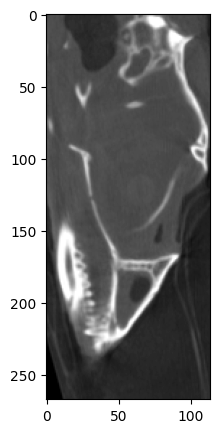

In [76]:
viridis = plt.get_cmap('gray')
fig, ax = plt.subplots()
fig.set_size_inches(10, 5)
ax.imshow(np.array(val[9]['image'], dtype=np.float32), cmap=viridis)

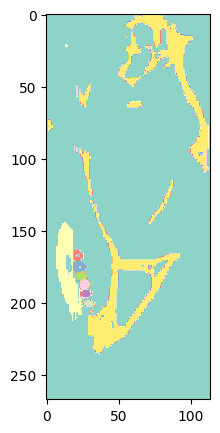

In [75]:
viridis = plt.get_cmap('Set3')
fig, ax = plt.subplots()
fig.set_size_inches(10, 5)
ax.imshow(np.array(val[9]['label'], dtype=np.float32), cmap=viridis)

c:\Users\pgmw9\Documents\Georgia Tech\HAAG\Lizard-Auto-Segmentation\venv\lib\site-packages\ipykernel_launcher.py:9: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  if __name__ == "__main__":


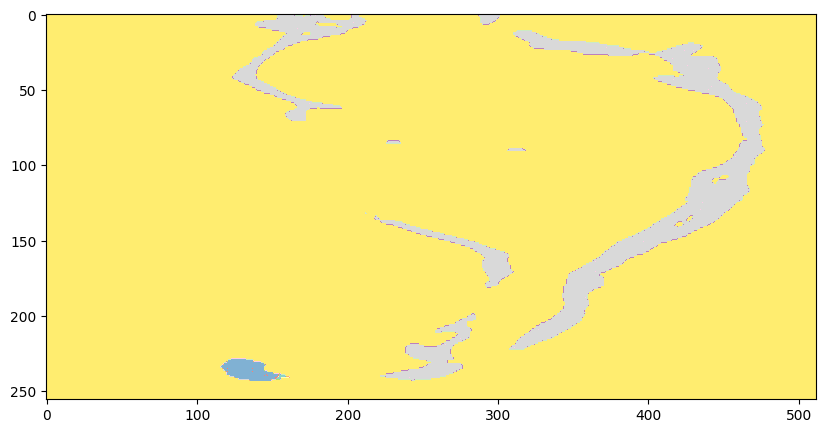

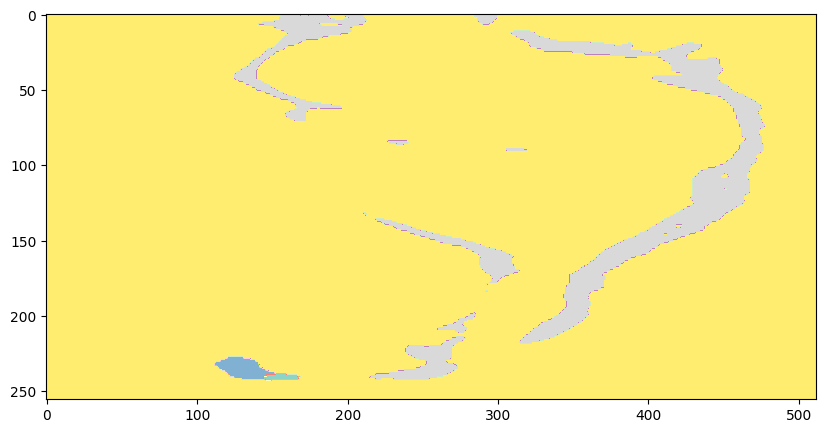

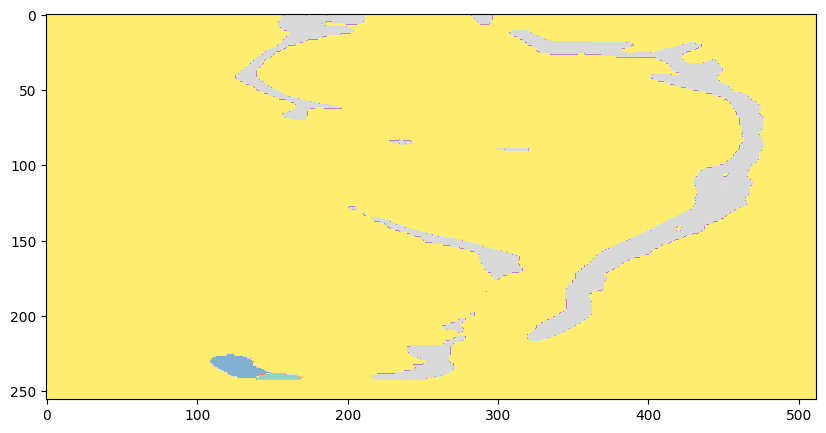

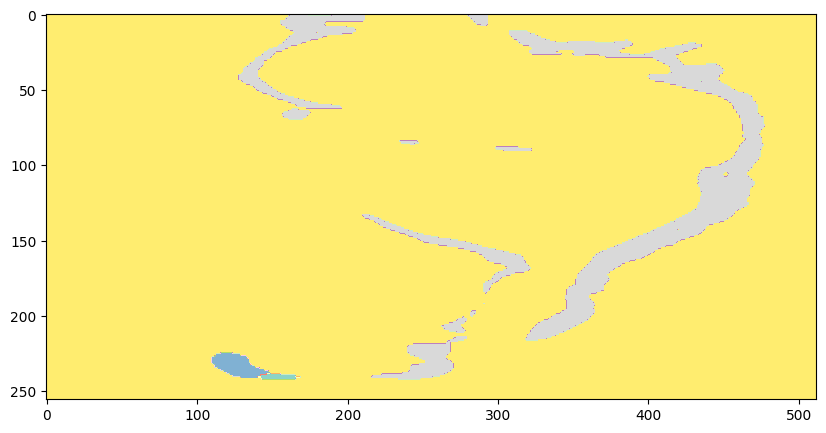

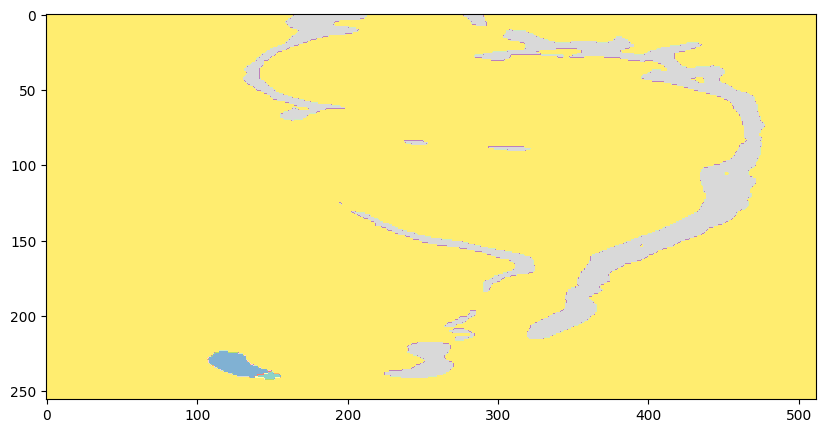

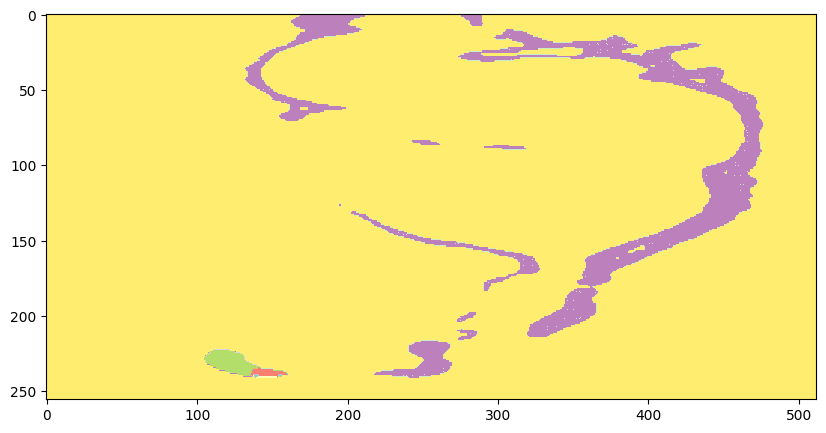

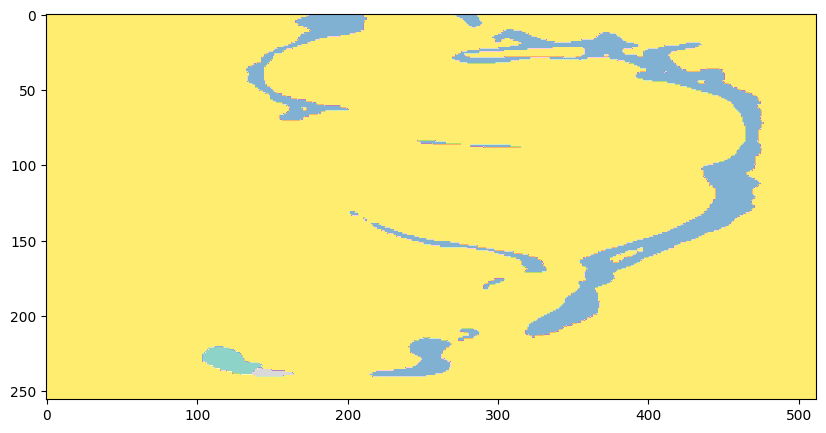

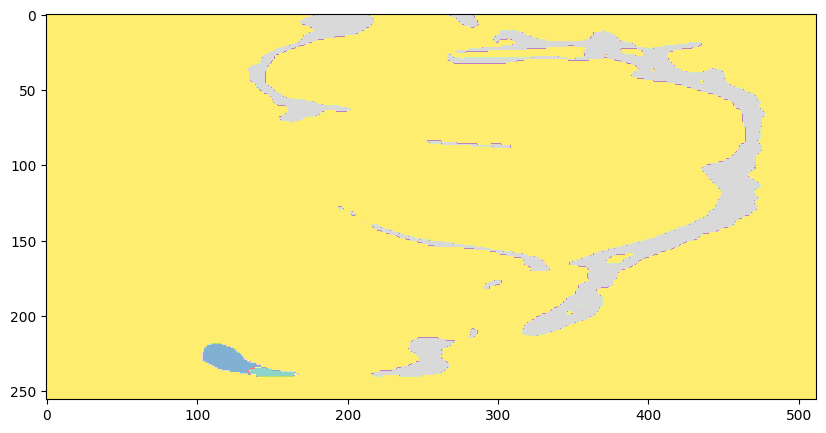

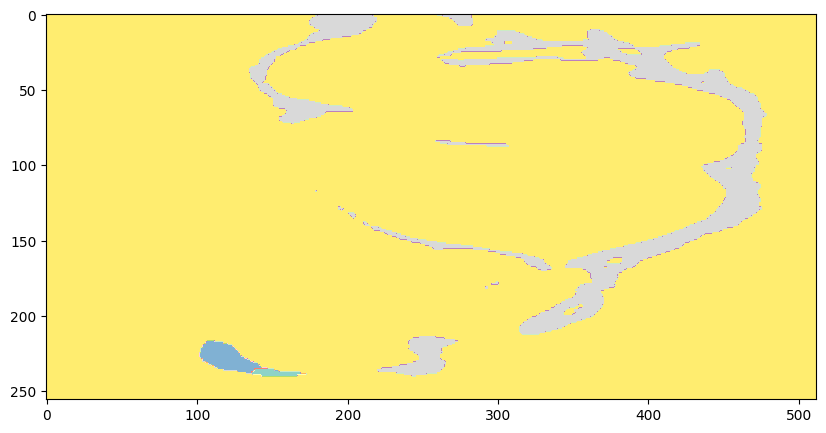

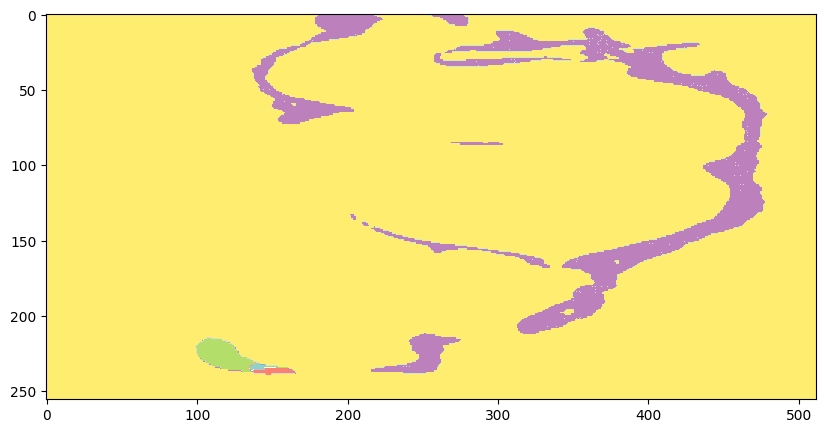

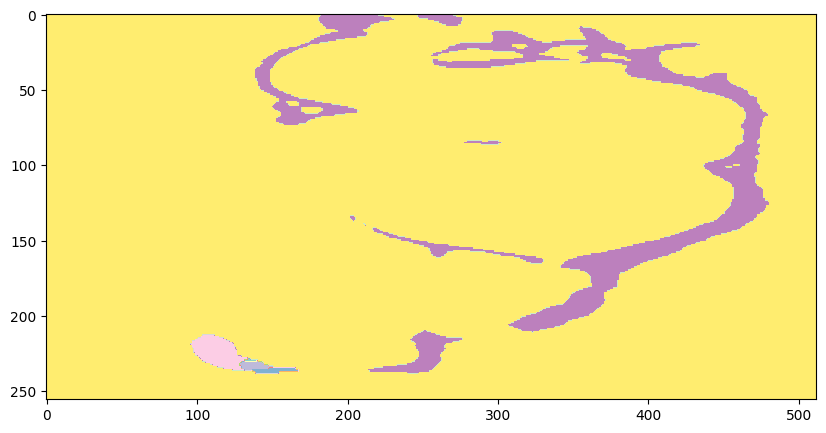

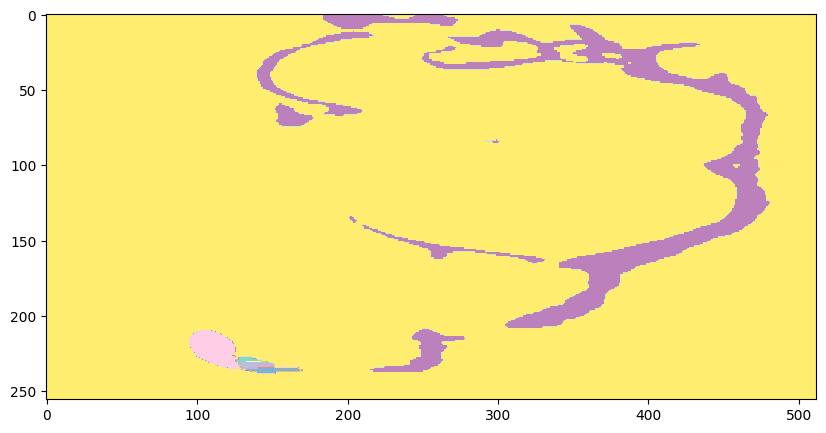

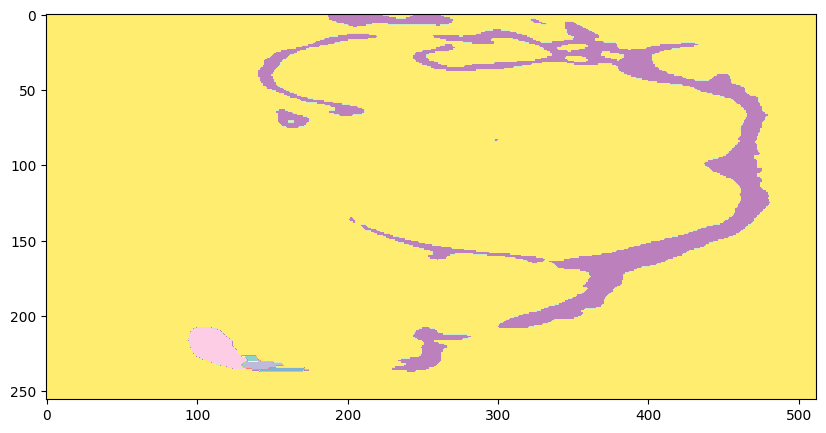

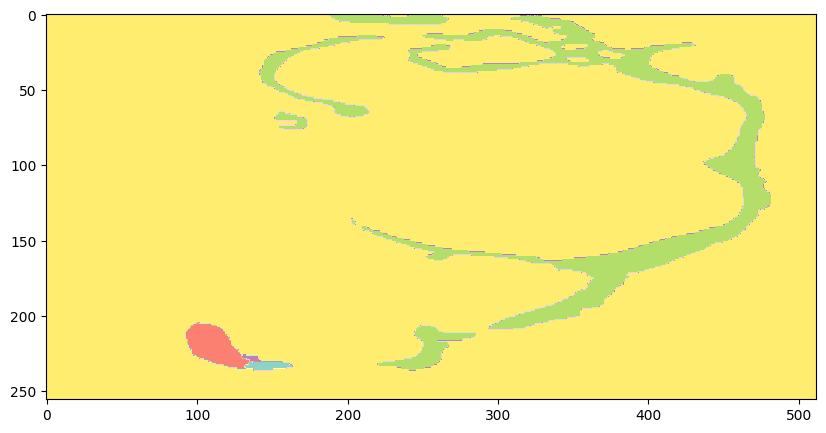

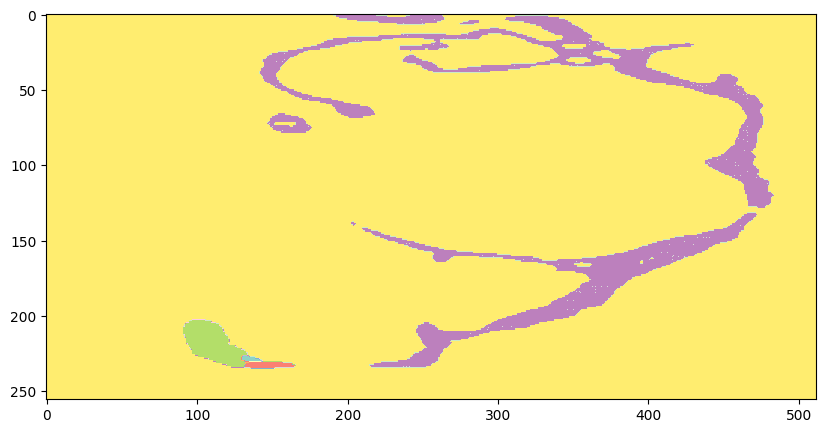

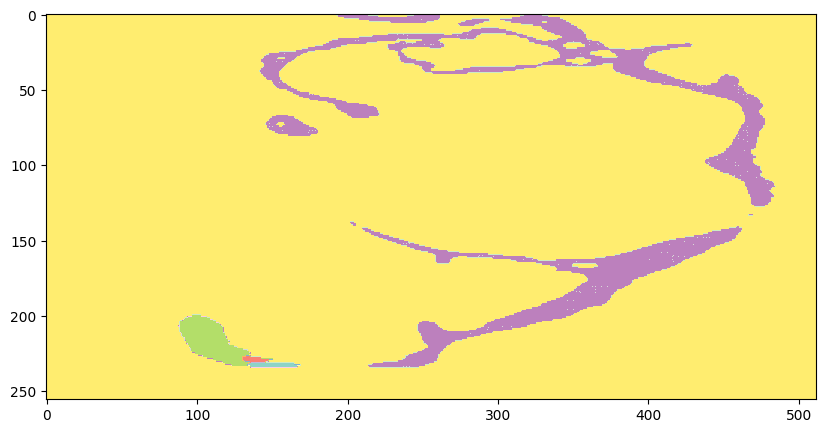

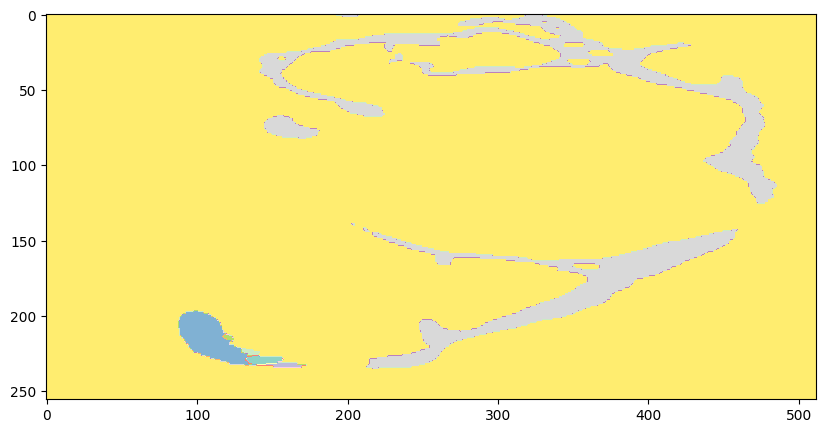

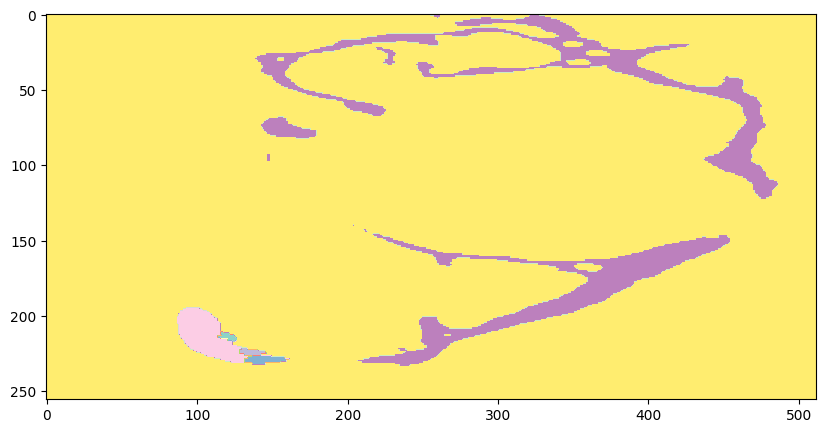

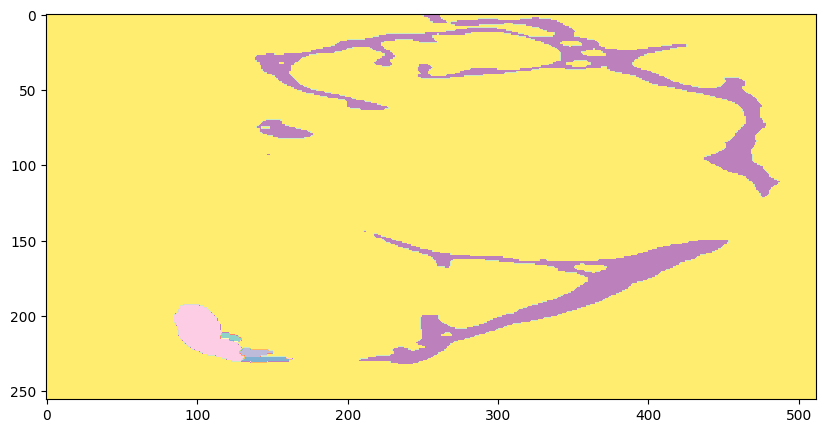

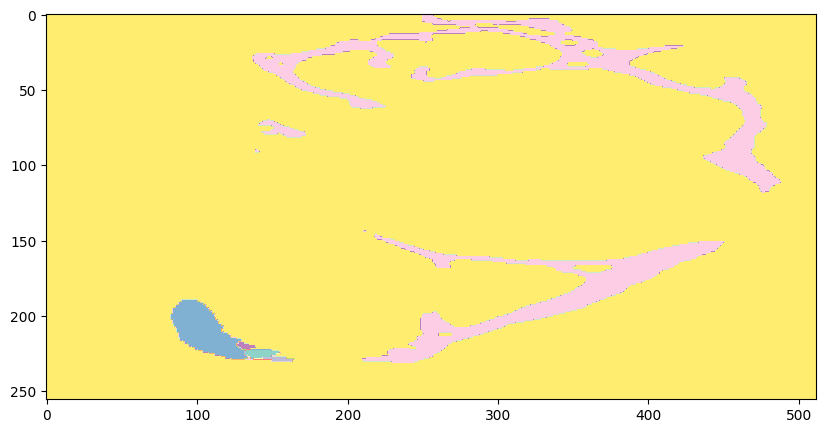

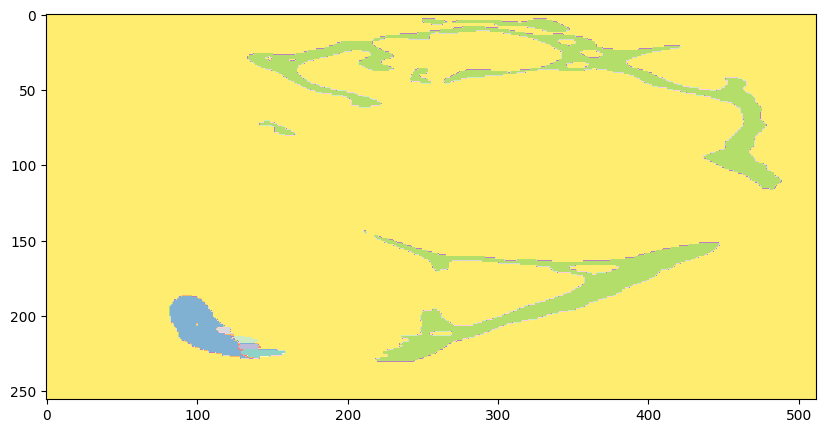

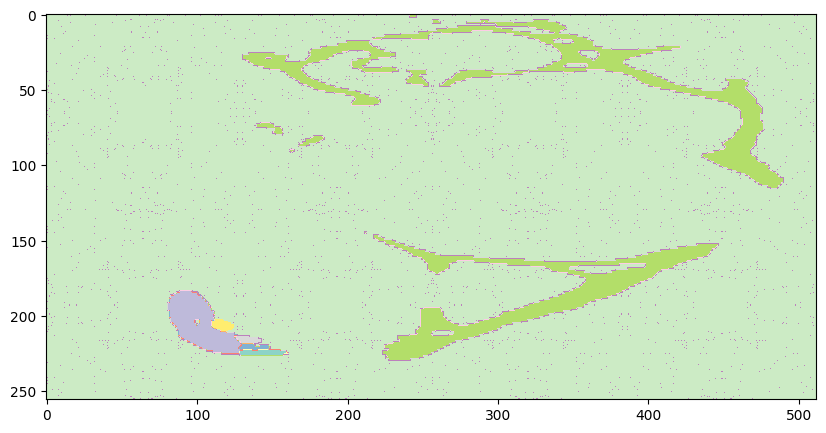

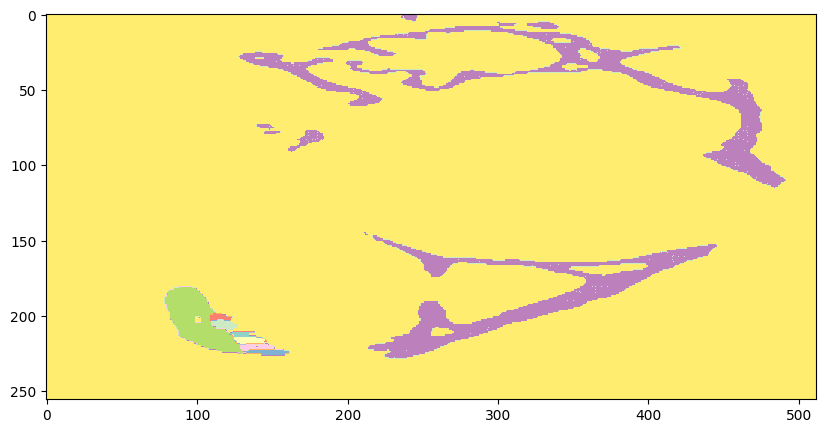

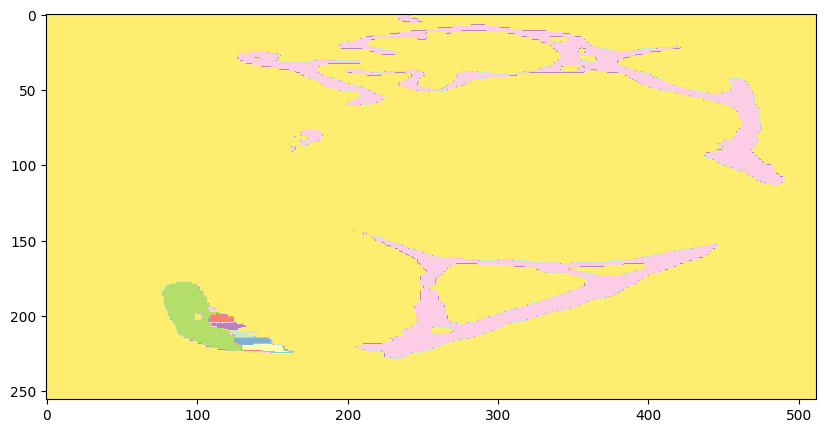

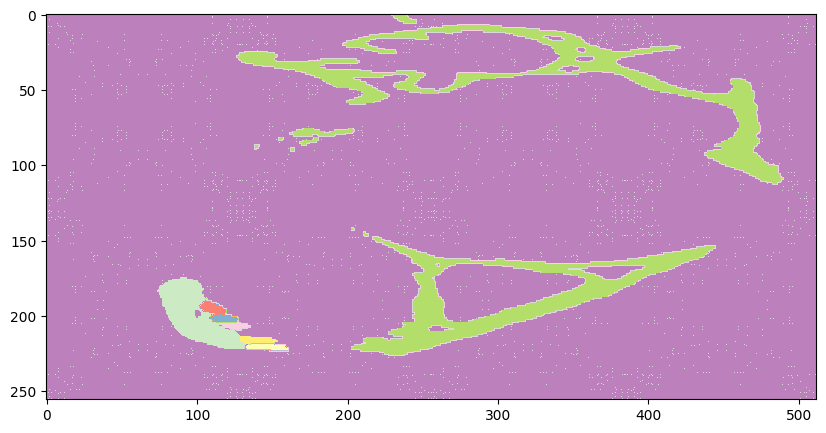

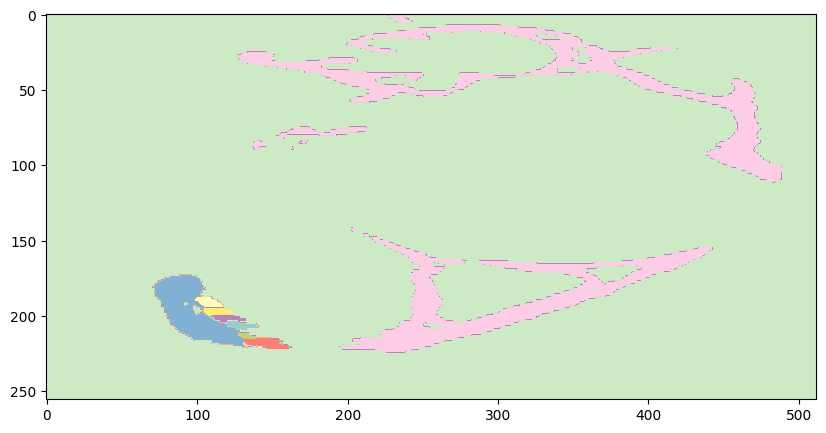

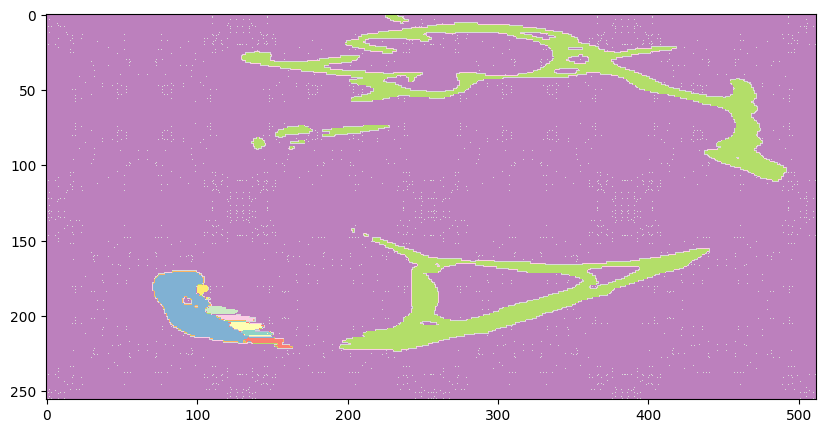

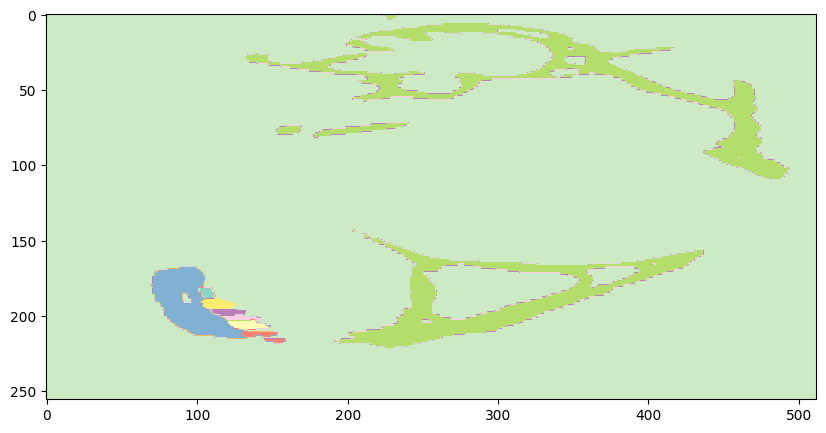

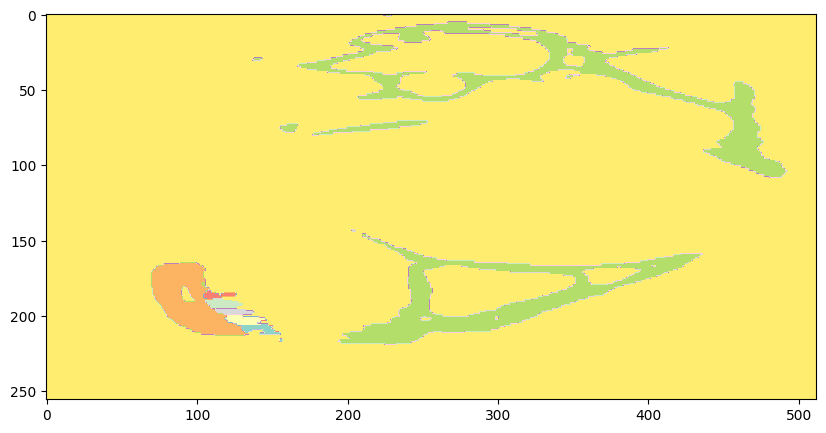

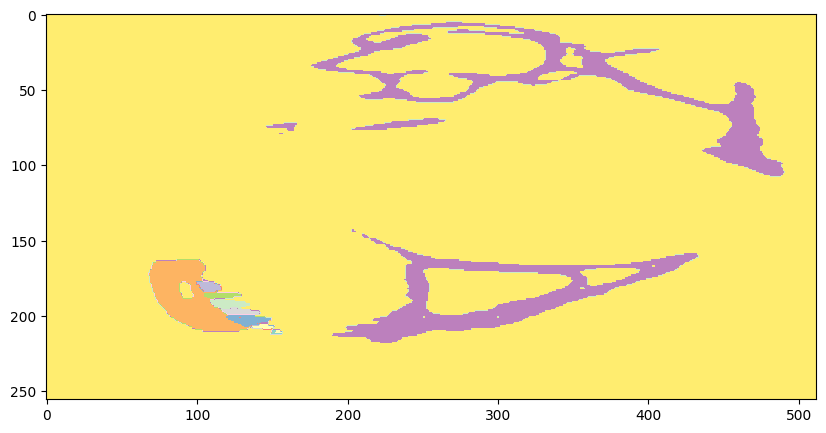

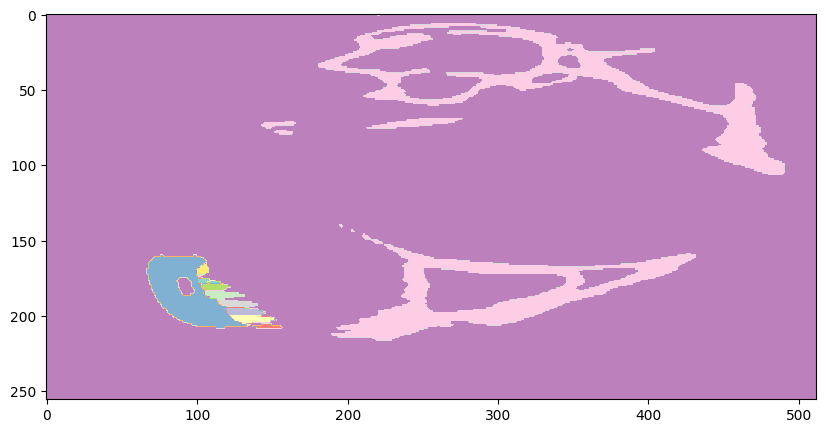

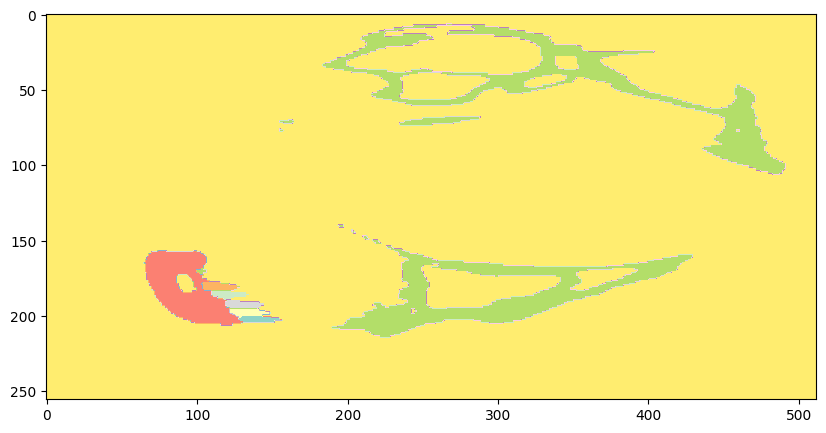

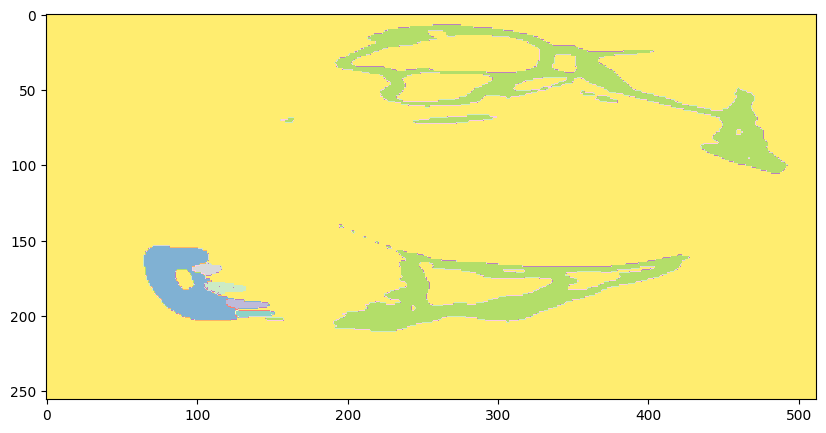

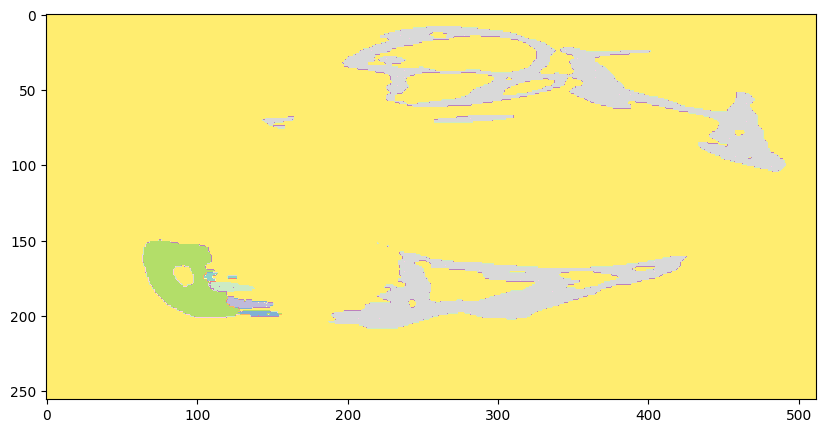

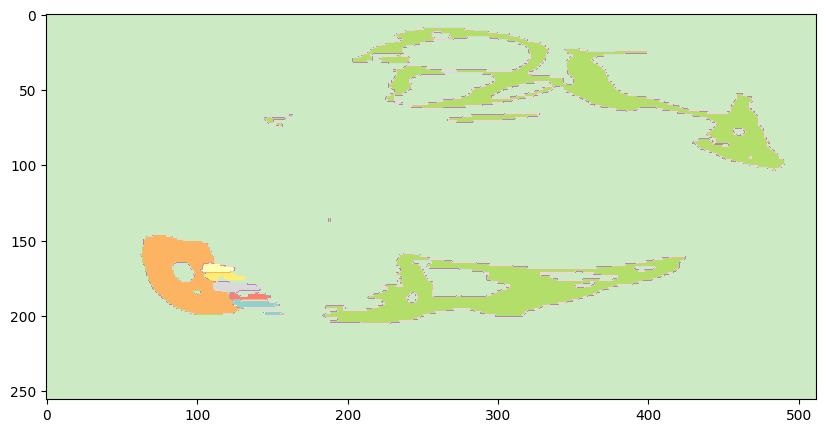

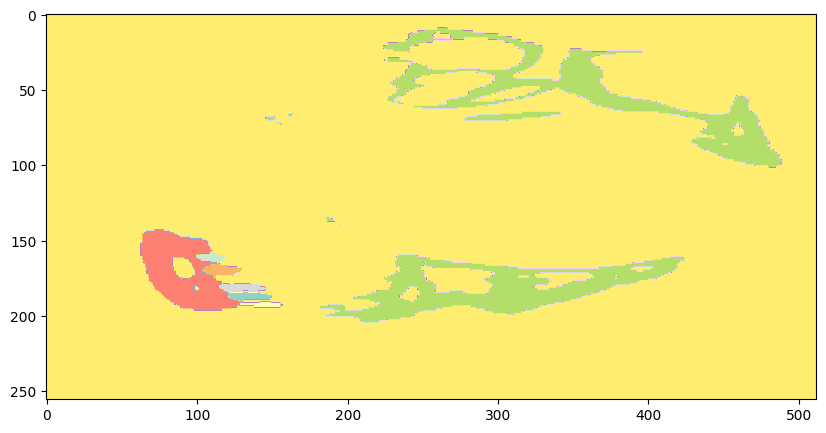

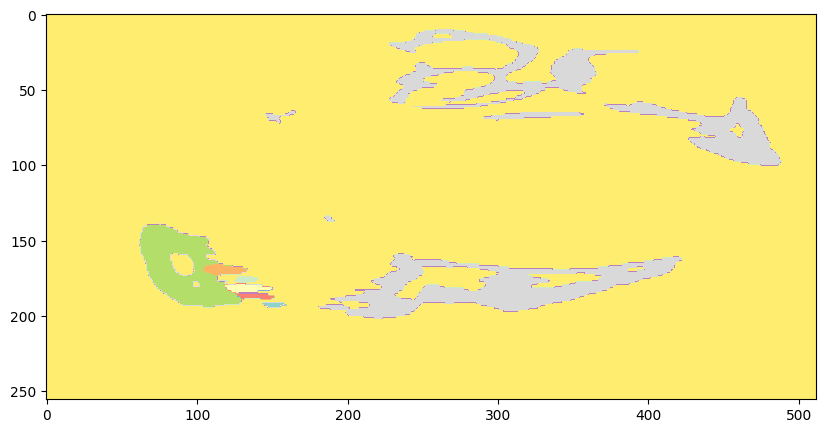

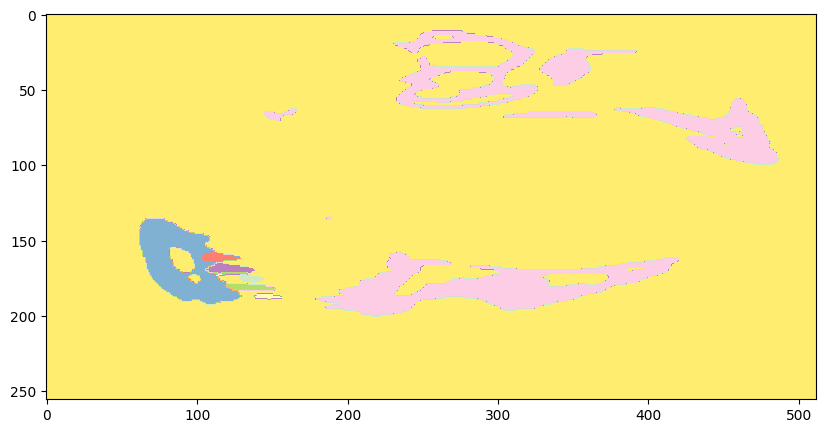

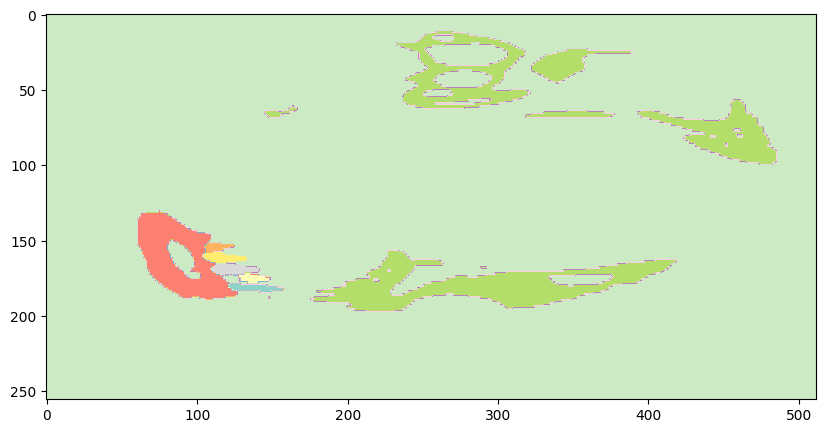

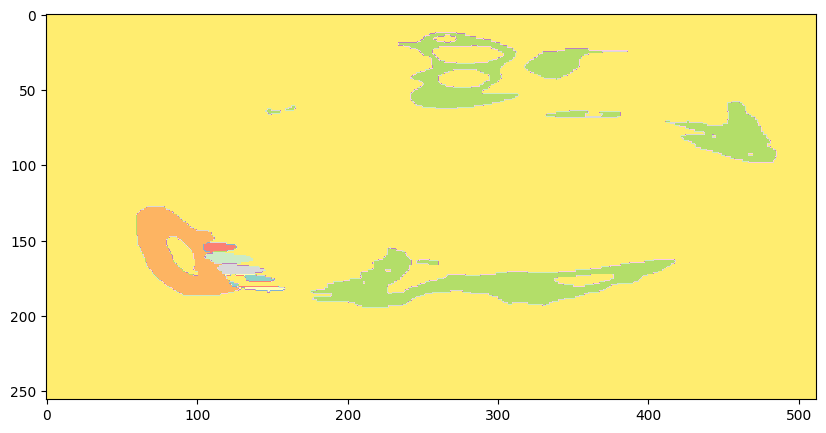

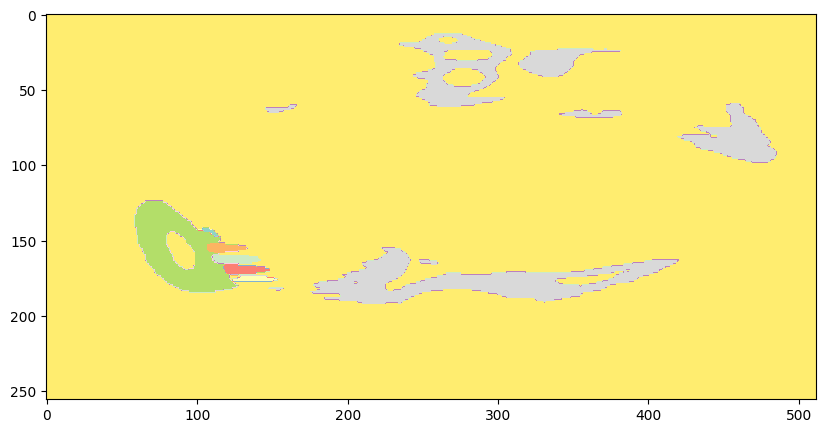

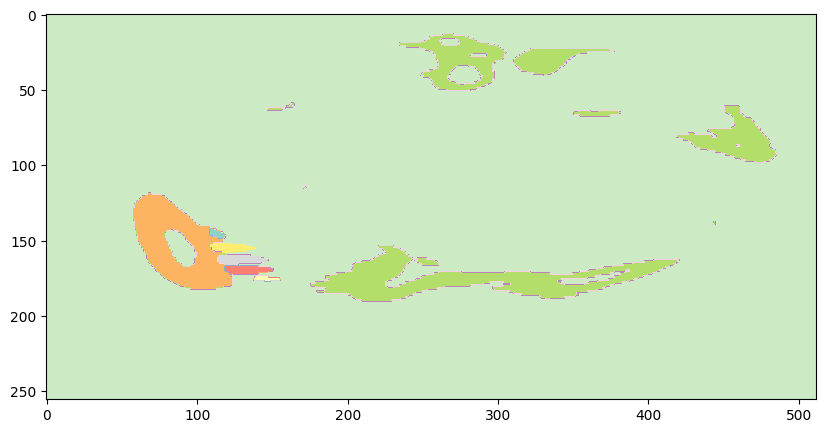

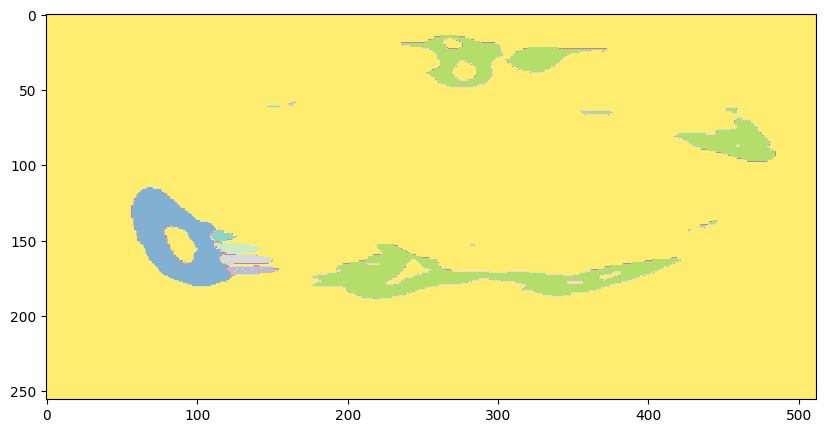

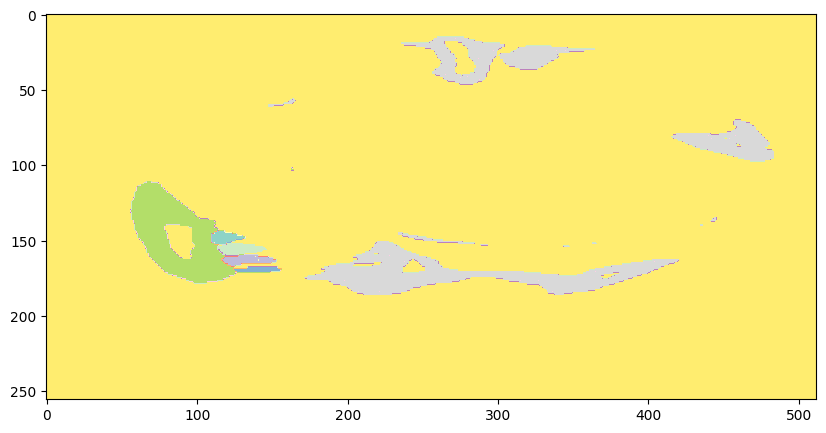

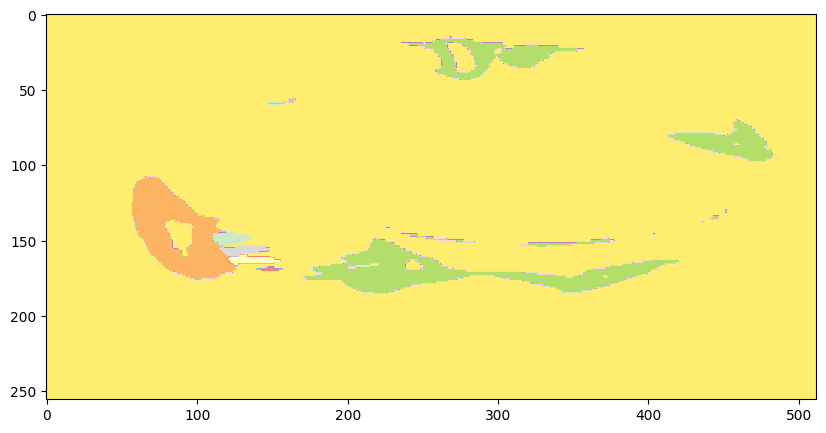

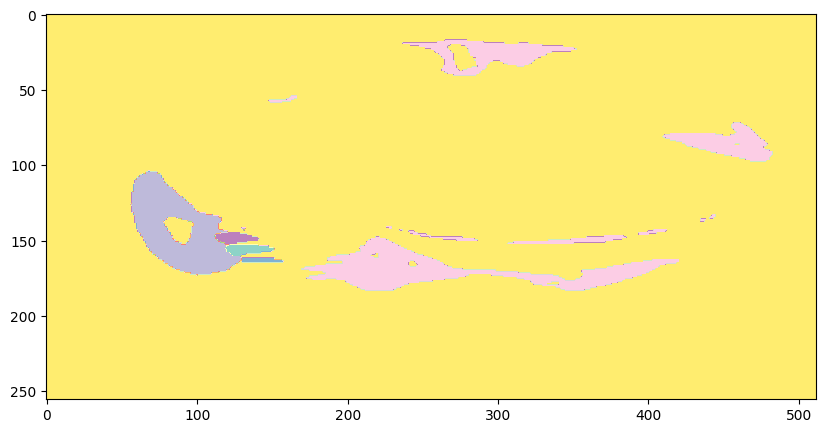

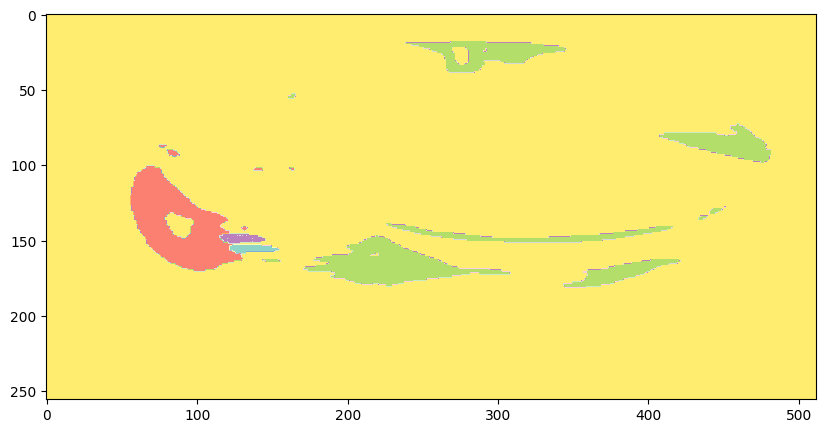

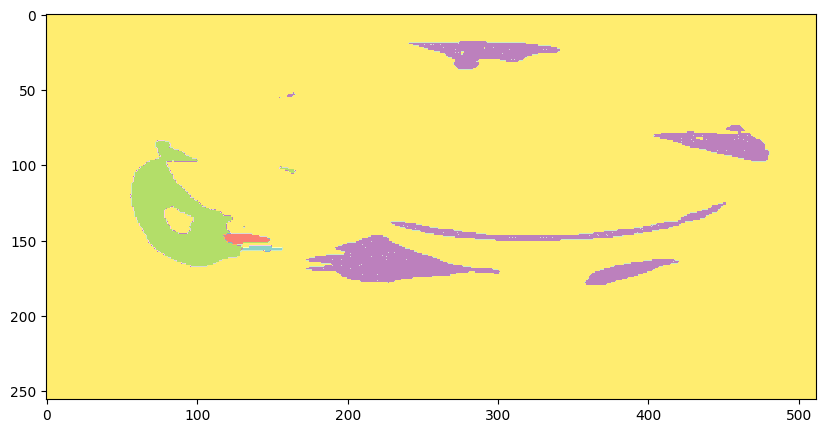

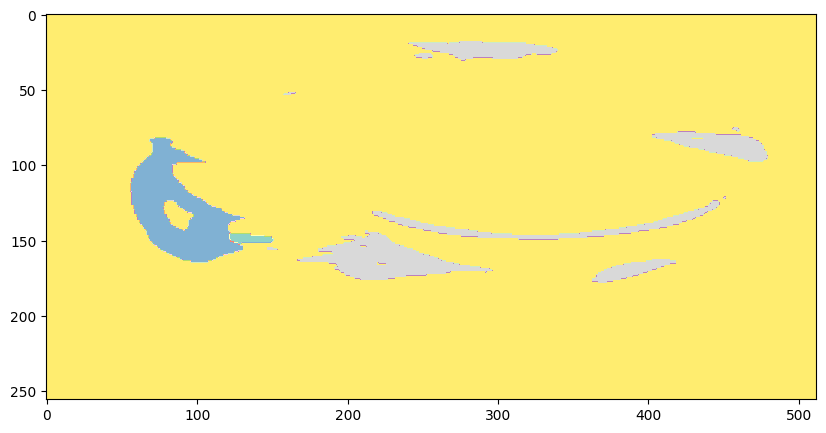

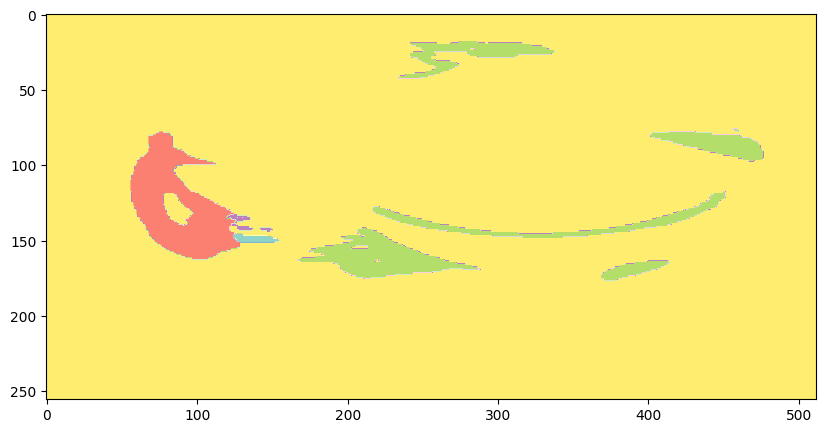

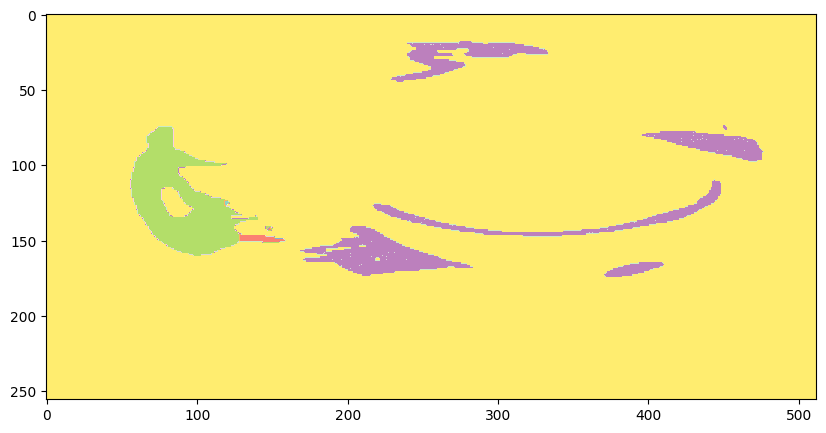

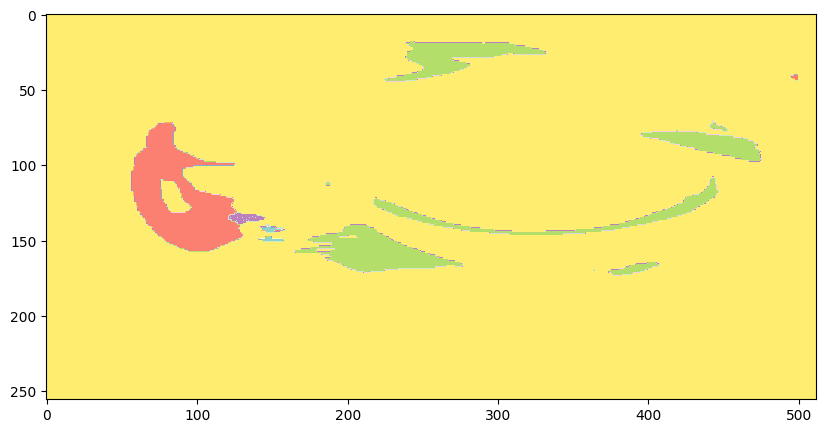

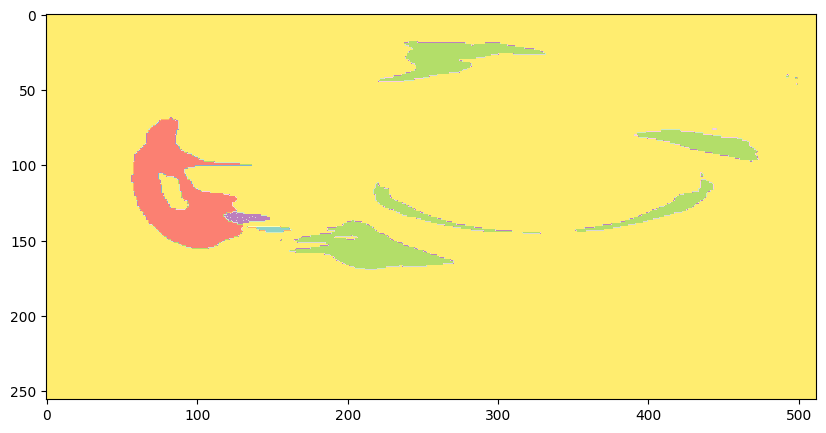

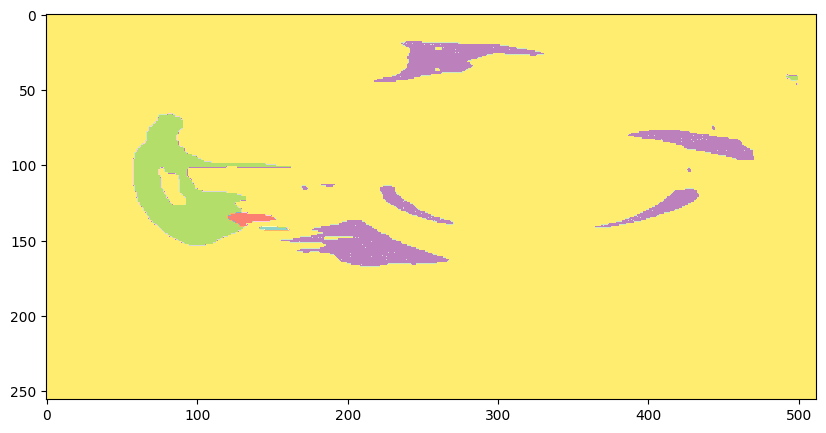

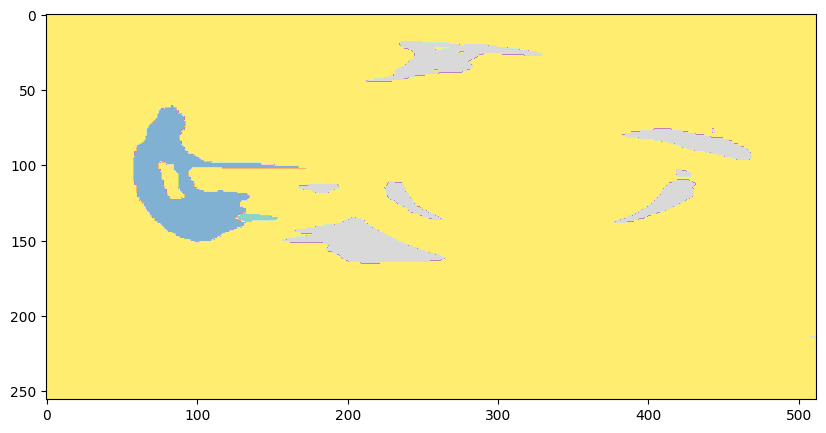

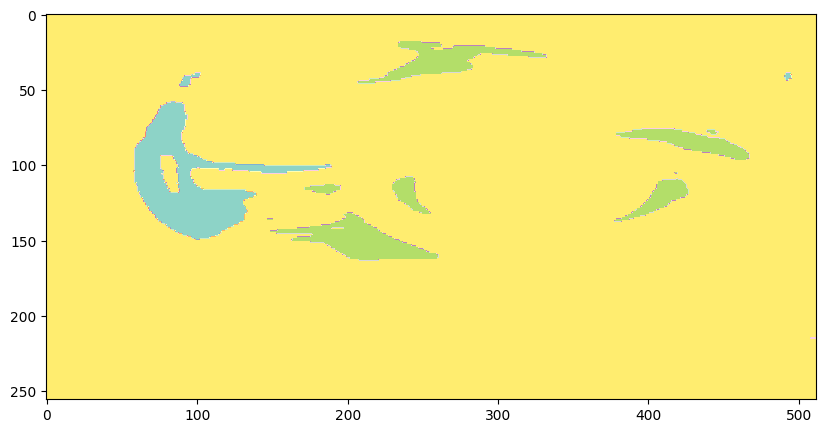

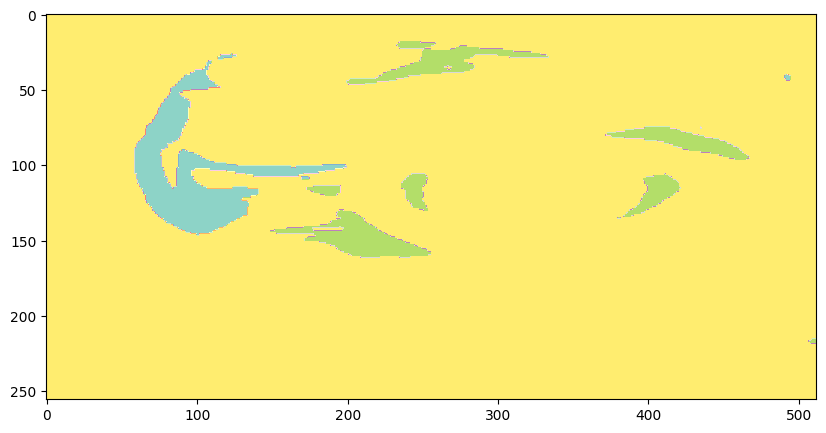

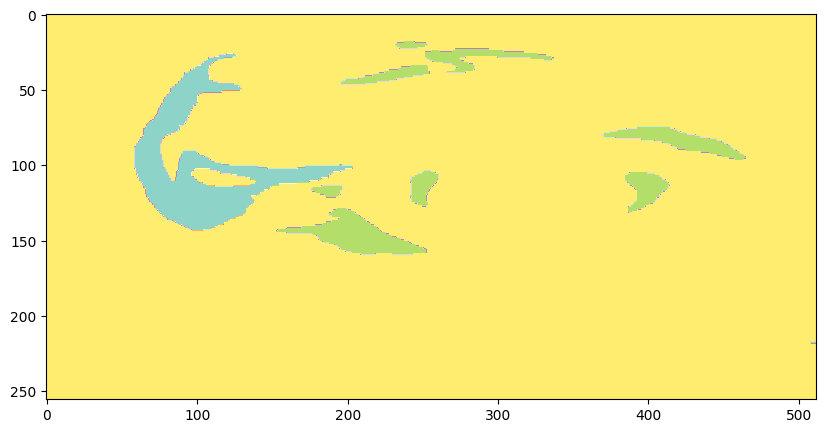

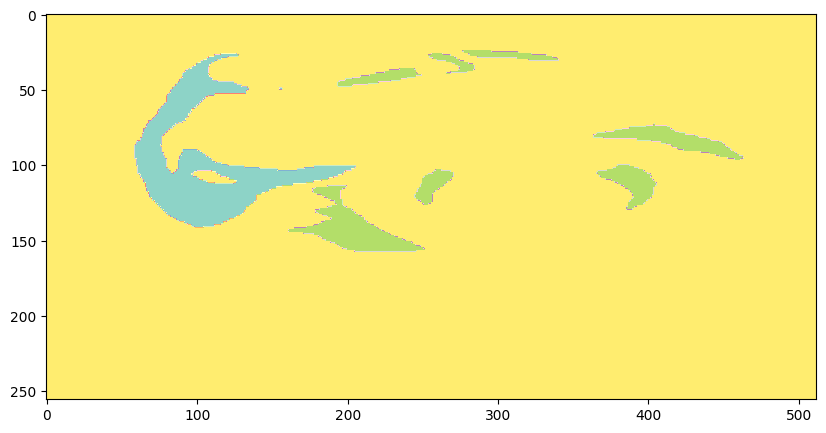

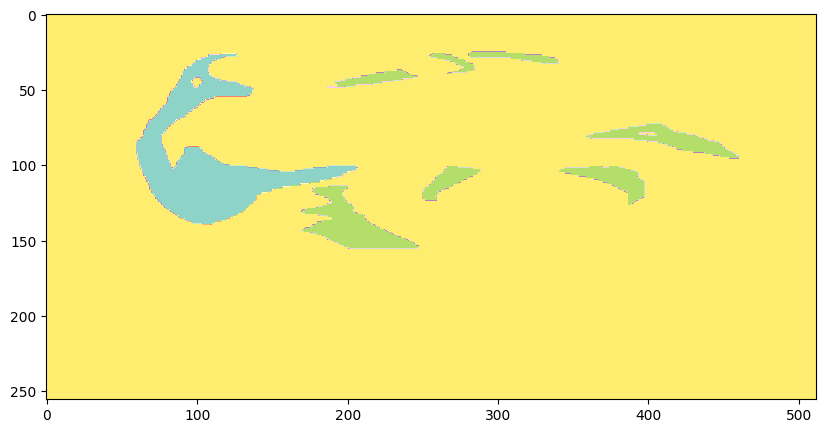

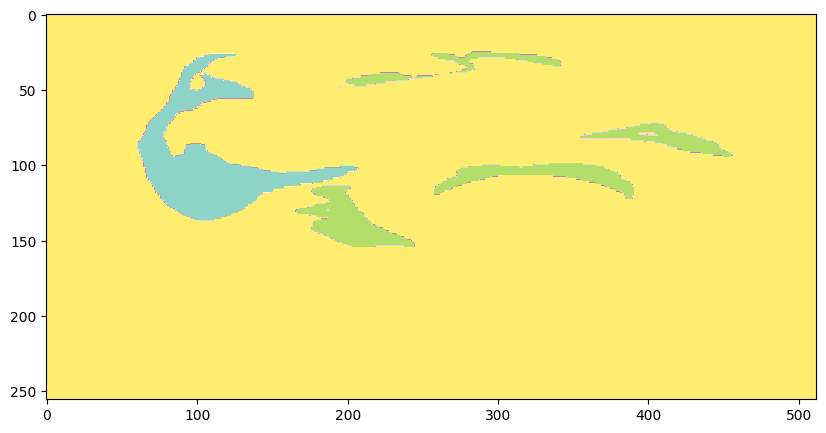

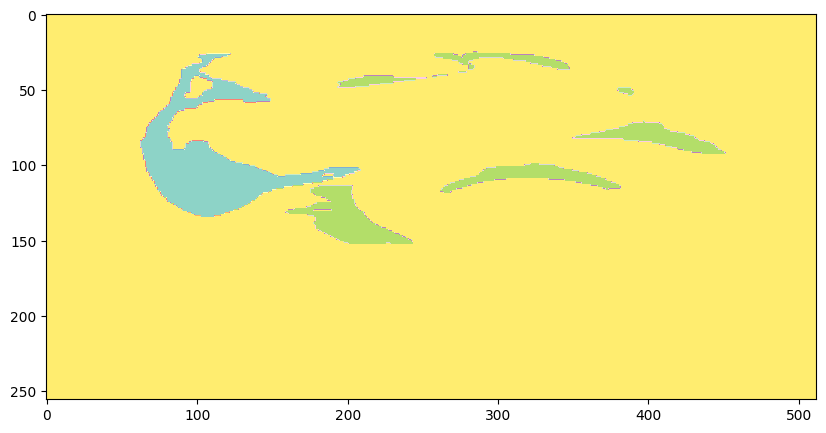

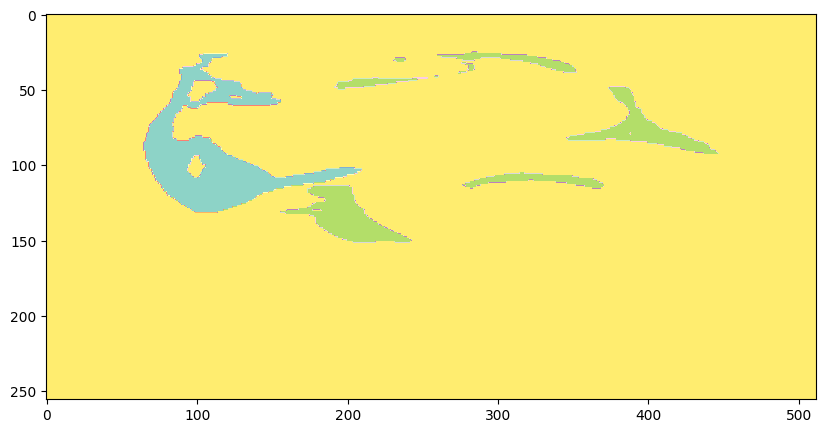

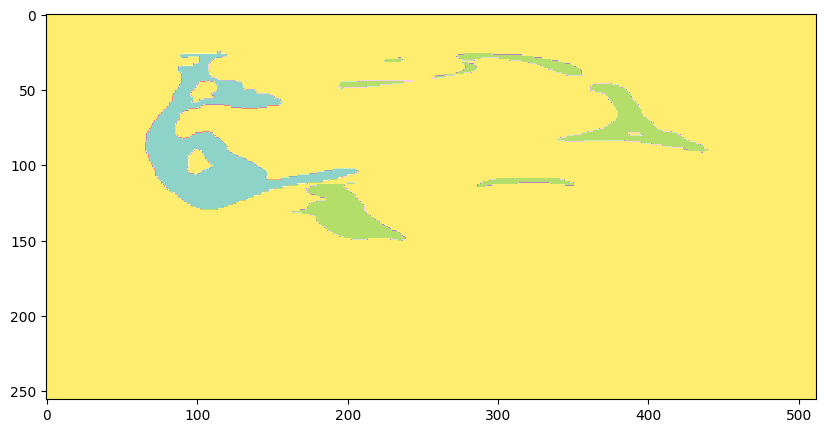

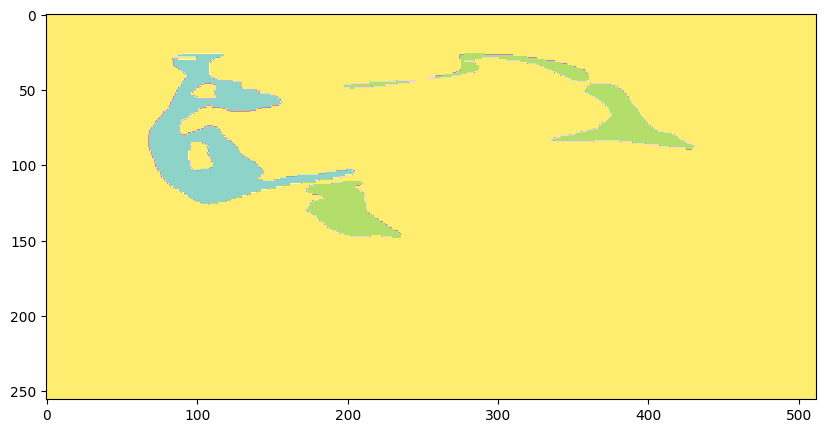

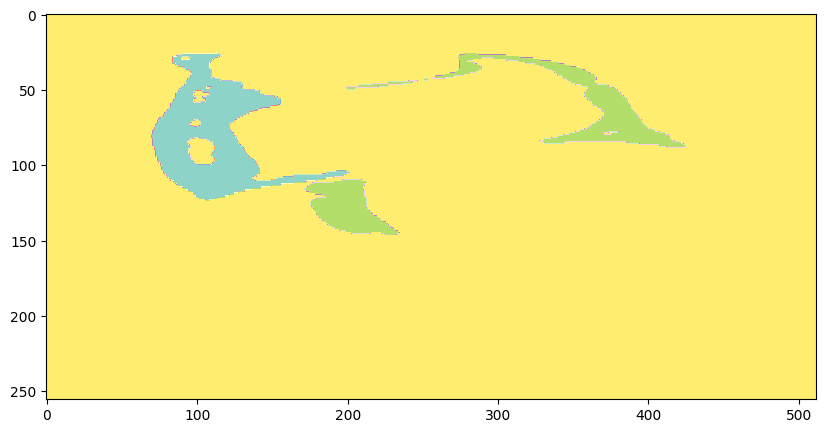

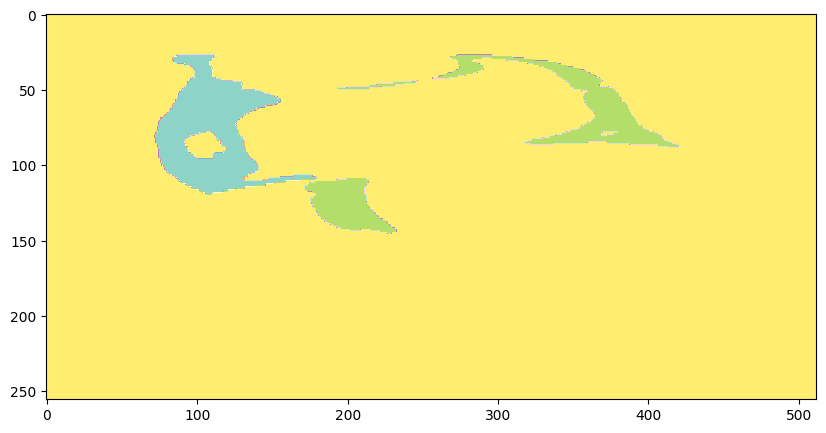

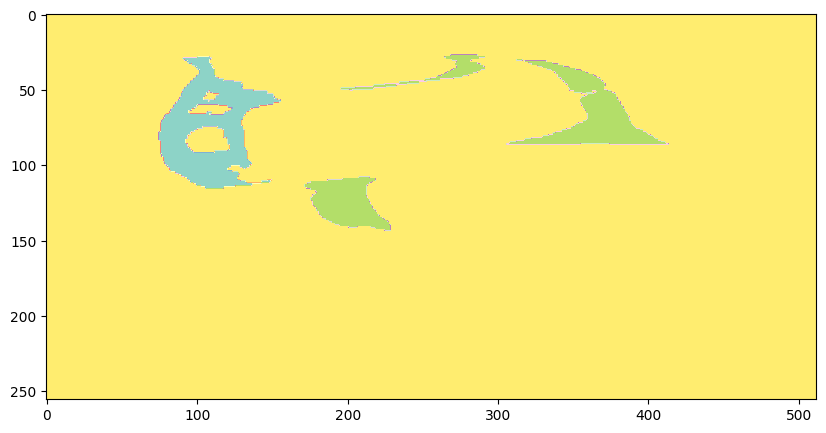

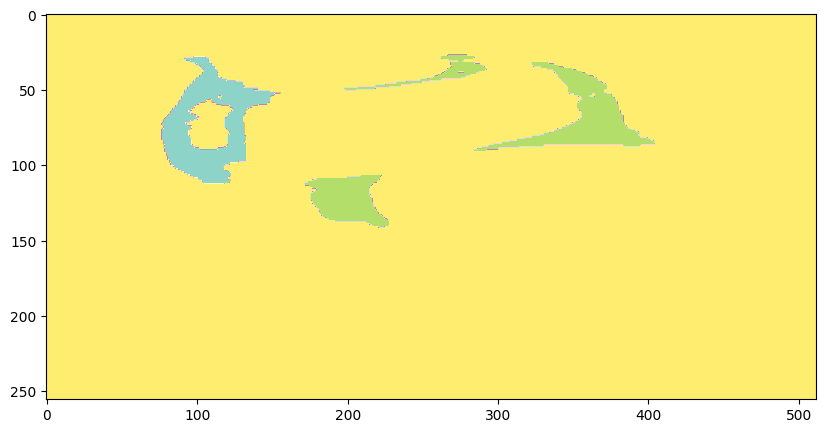

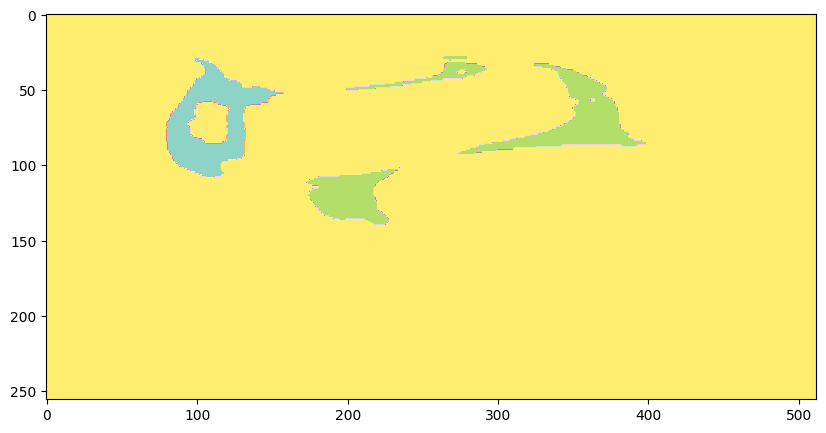

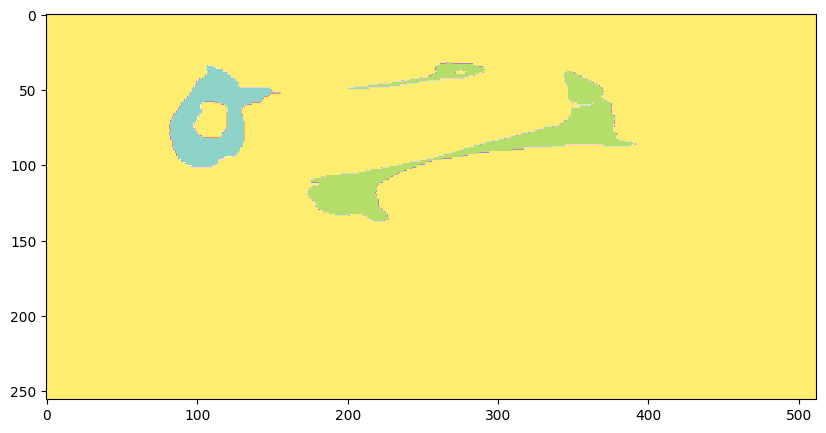

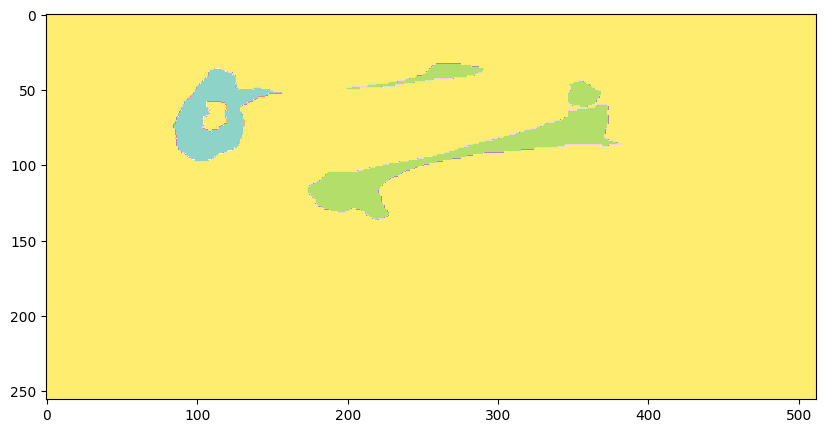

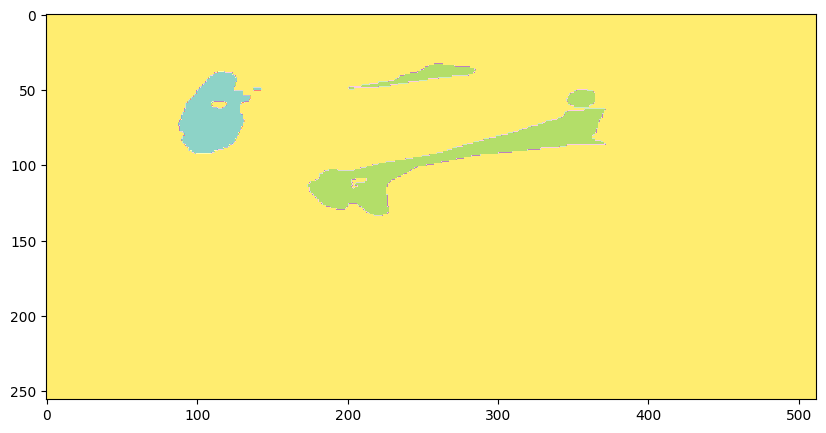

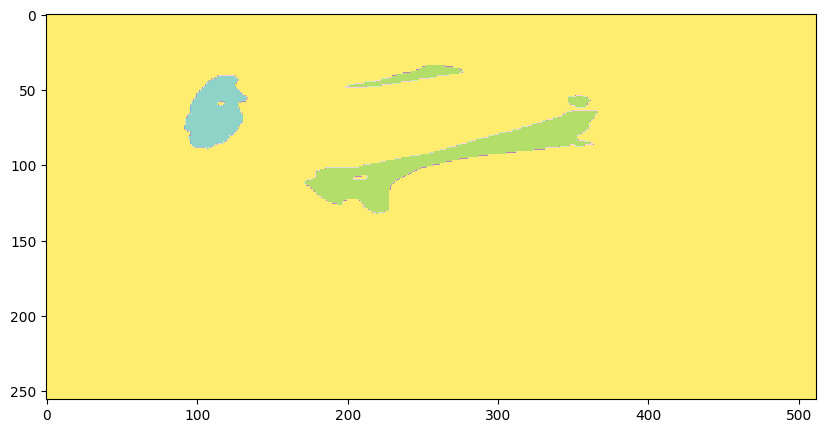

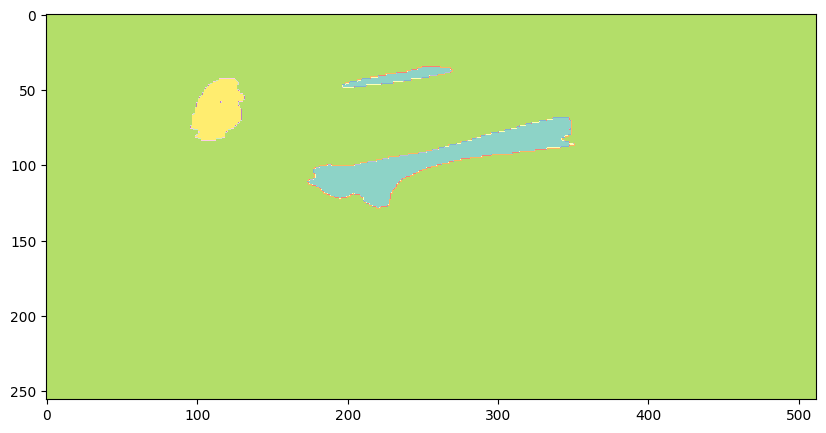

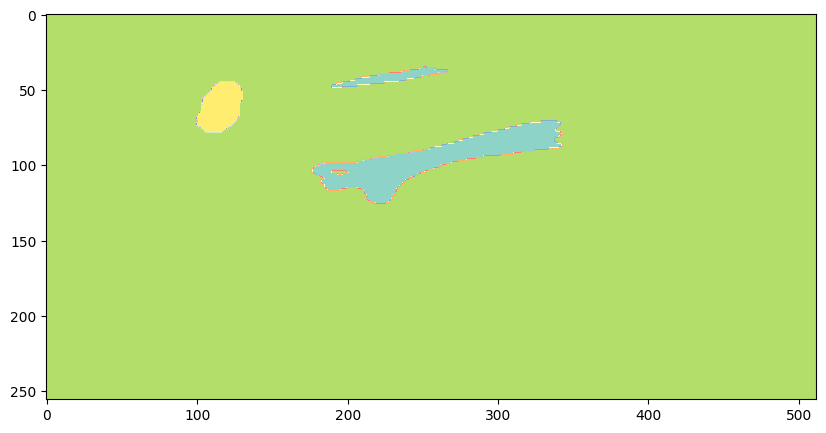

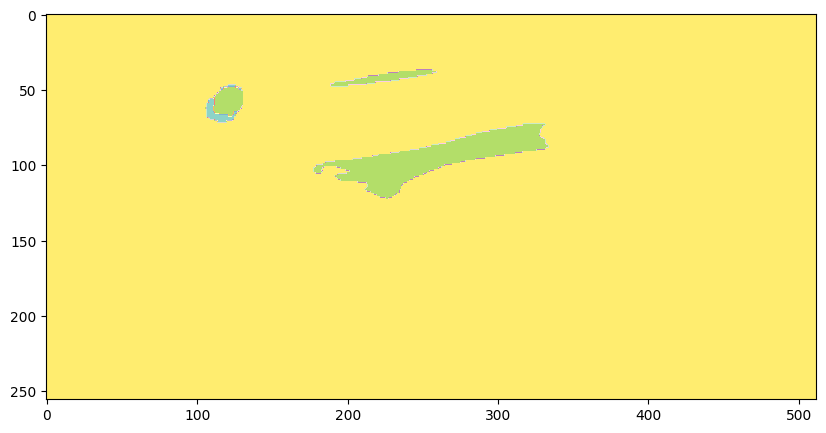

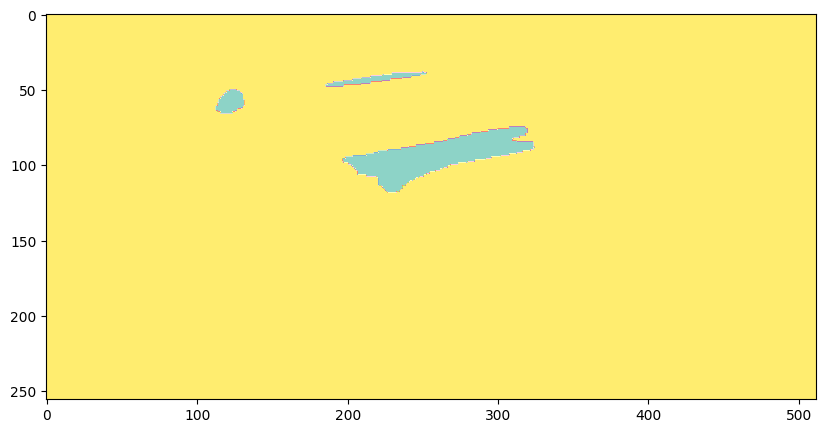

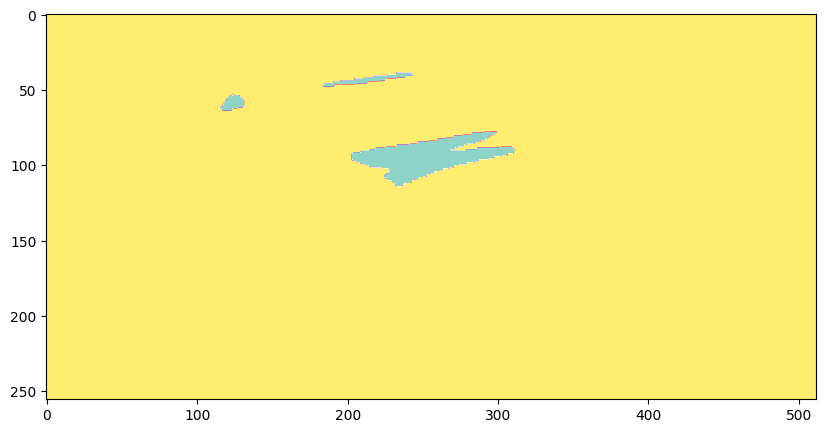

In [13]:
#save outlist to disk

In [10]:
draw_panoptic_segmentation(tlist[0]['label'], tlist[0]['segments_info'])

IndexError: too many indices for tensor of dimension 4

In [11]:
outlist[0]['segmentation'].cpu()

tensor([[6, 6, 6,  ..., 6, 6, 6],
        [6, 6, 6,  ..., 6, 6, 6],
        [6, 6, 6,  ..., 6, 6, 6],
        ...,
        [6, 6, 6,  ..., 6, 6, 6],
        [6, 6, 6,  ..., 6, 6, 6],
        [6, 6, 6,  ..., 6, 6, 6]], dtype=torch.int32)

IndexError: too many indices for tensor of dimension 4

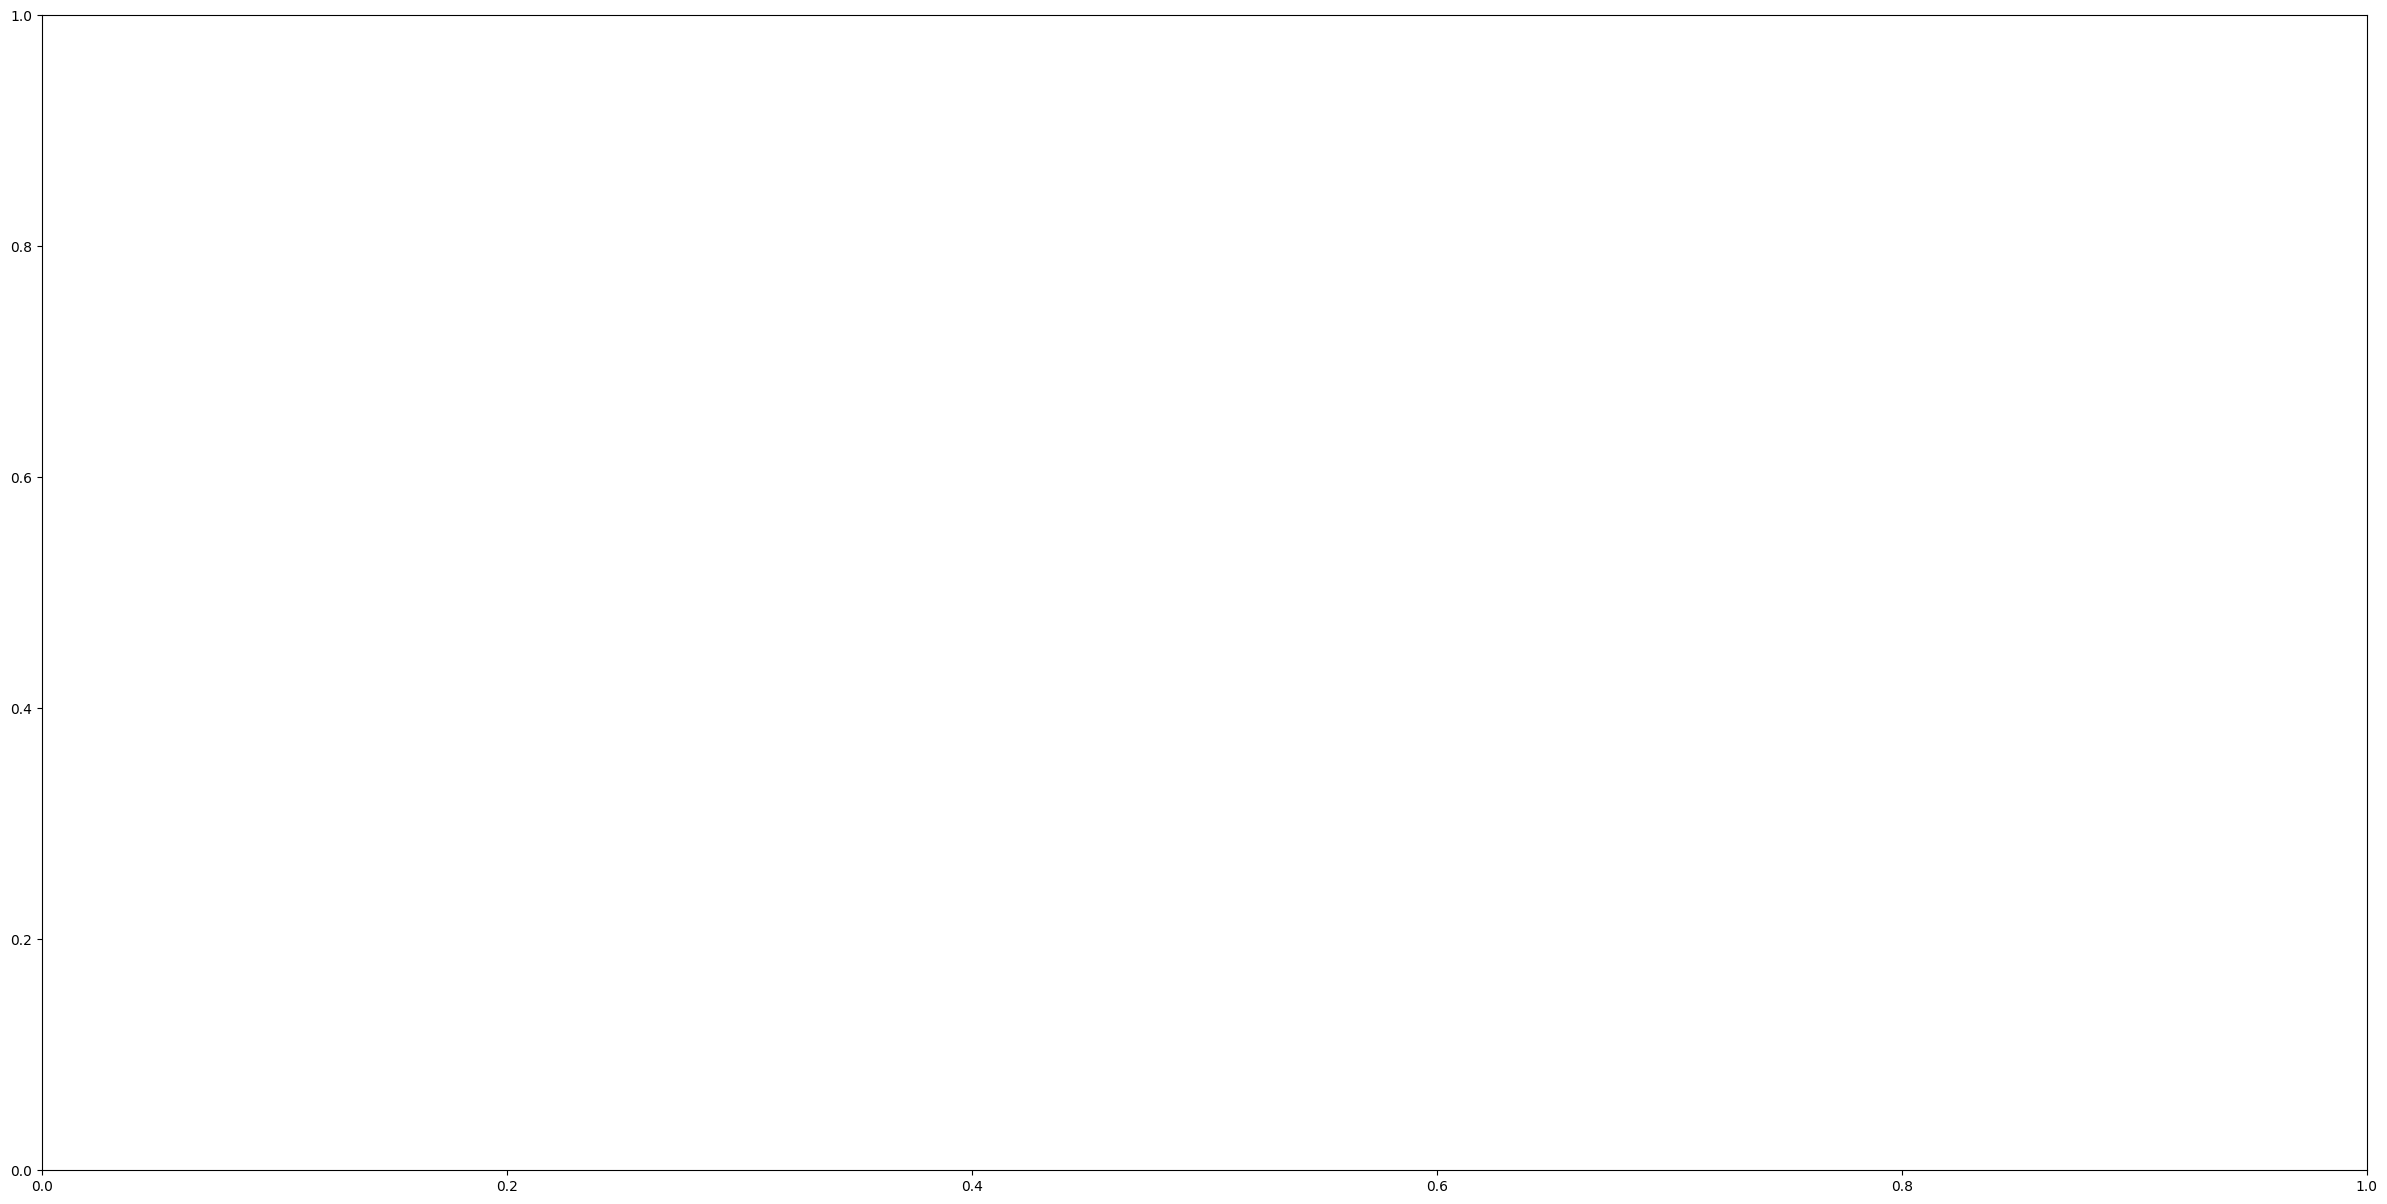

In [15]:
    viridis = plt.get_cmap('gray')
    fig, ax = plt.subplots()
    fig.set_size_inches(30, 15)
    ax.imshow(tlist[0]['image'], cmap=viridis)
    plt.savefig("image.png")

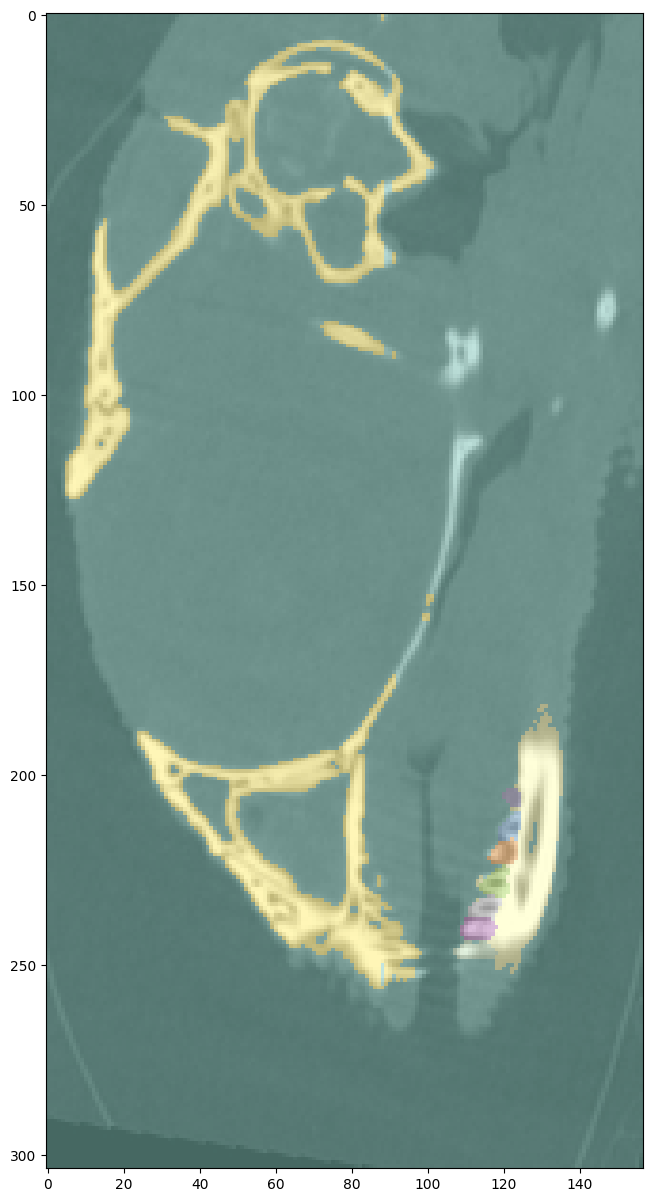

In [80]:
    viridis = plt.get_cmap('gray')
    fig, ax = plt.subplots()
    fig.set_size_inches(30, 15)
    ax.imshow(tlist[0]['image'], cmap=viridis)
    ax.imshow(tlist[0]['label'], cmap="Set3", alpha=0.5)
    plt.savefig("actual label.png")

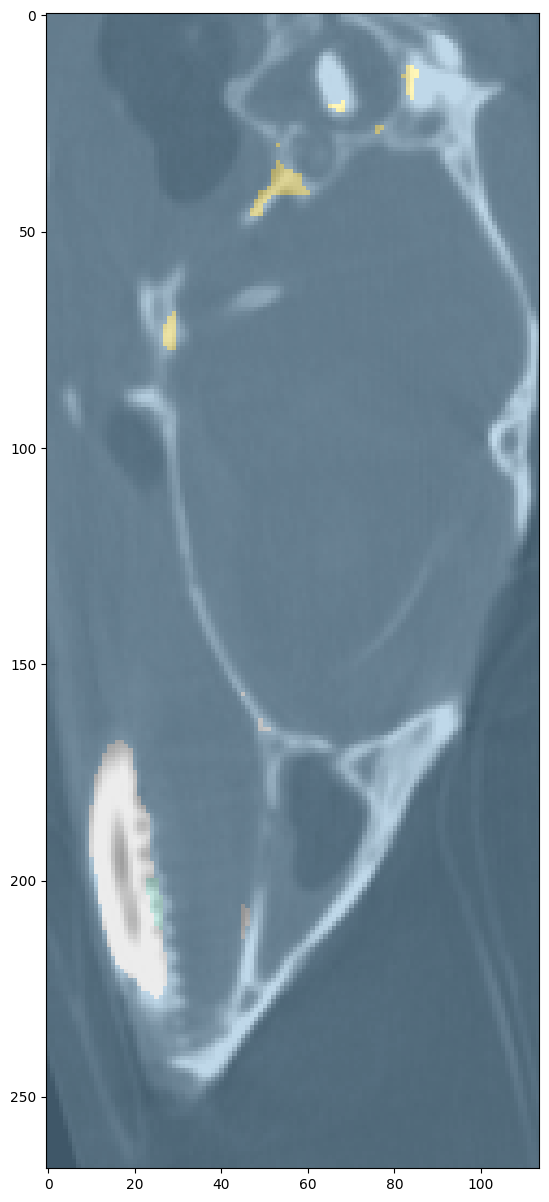

In [66]:
    viridis = plt.get_cmap('gray')
    fig, ax = plt.subplots()
    fig.set_size_inches(30, 15)
    ax.imshow(tlist[15][0, 1, :, :], cmap=viridis)
    ax.imshow((outlist[15]['segmentation'].cpu()), cmap="Set3", alpha=0.5)
    plt.savefig("predicted label.png")